# Phase 3.3 - Model Training

In this phase, multiple supervised machine learning models will be trained and evaluated using the finalized datasets prepared during the previous phase.

Unlike exploratory notebooks, this notebook is fully reproducible and independent. All datasets are loaded directly from the project's `data/final/` directory.

Every model will be trained using the same finalized training dataset and evaluated on the same testing dataset to ensure fair and consistent comparison.

## 3.3.1 Prepare Modeling Environment

Before training any machine learning model, the finalized datasets are loaded and verified.

This step ensures:

- Independent notebook execution
- Reproducible experiments
- Consistent datasets for every model
- Standardized evaluation pipeline

In [1]:
from pathlib import Path

import pandas as pd

# Final dataset directory
final_data_dir = Path("../data/final")

# Load datasets
X_train_final = pd.read_csv(final_data_dir / "X_train_final.csv")
y_train_final = pd.read_csv(final_data_dir / "y_train_final.csv").squeeze("columns")

X_test_final = pd.read_csv(final_data_dir / "X_test_final.csv")
y_test_final = pd.read_csv(final_data_dir / "y_test_final.csv").squeeze("columns")

print("Final datasets loaded successfully.")

Final datasets loaded successfully.


In [2]:
print("=" * 60)
print("Dataset Verification")
print("=" * 60)

print(f"X_train_final : {X_train_final.shape}")
print(f"y_train_final : {y_train_final.shape}")

print(f"X_test_final  : {X_test_final.shape}")
print(f"y_test_final  : {y_test_final.shape}")

Dataset Verification
X_train_final : (453204, 33)
y_train_final : (453204,)
X_test_final  : (28373, 33)
y_test_final  : (28373,)


In [3]:
candidate_models = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "LightGBM (Optional)"
    ],
    "Category": [
        "Linear",
        "Bagging",
        "Boosting",
        "Boosting"
    ],
    "Status": [
        "Pending",
        "Pending",
        "Pending",
        "Optional"
    ]
})

candidate_models

,Model,Category,Status
0,Logistic Regression,Linear,Pending
1,Random Forest,Bagging,Pending
2,XGBoost,Boosting,Pending
3,LightGBM (Optional),Boosting,Optional


# 3.3.2 Train Logistic Regression

Logistic Regression is selected as the first benchmark model because it is simple, interpretable, and computationally efficient.

Although fraud detection problems often benefit from more advanced ensemble and boosting algorithms, Logistic Regression provides an excellent baseline for evaluating whether more complex models actually improve predictive performance.

The model is trained using the finalized SMOTE-balanced training dataset and evaluated on the untouched testing dataset.

In [4]:
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
)

In [5]:
logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logistic_model

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [6]:
logistic_model.fit(
    X_train_final,
    y_train_final
)

print("✅ Logistic Regression model trained successfully.")

✅ Logistic Regression model trained successfully.


In [7]:
# Class predictions
y_pred_lr = logistic_model.predict(X_test_final)

# Prediction probabilities
y_prob_lr = logistic_model.predict_proba(X_test_final)[:, 1]

print("✅ Predictions generated successfully.")

✅ Predictions generated successfully.


In [8]:
logistic_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "PR-AUC"
    ],
    "Value": [
        accuracy_score(y_test_final, y_pred_lr),
        precision_score(y_test_final, y_pred_lr),
        recall_score(y_test_final, y_pred_lr),
        f1_score(y_test_final, y_pred_lr),
        roc_auc_score(y_test_final, y_prob_lr),
        average_precision_score(y_test_final, y_prob_lr),
    ]
})

logistic_metrics

,Metric,Value
0,Accuracy,0.973038
1,Precision,0.053483
2,Recall,0.914894
3,F1-Score,0.101058
4,ROC-AUC,0.983142
5,PR-AUC,0.710773


## 3.3.2.6 Confusion Matrix

The confusion matrix summarizes the classification performance of the Logistic Regression model by comparing the predicted labels with the actual labels.

It provides the counts of:

- True Positives (TP)
- True Negatives (TN)
- False Positives (FP)
- False Negatives (FN)

Since fraud detection is an imbalanced classification problem, the confusion matrix offers more meaningful insights than overall accuracy alone.

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt

In [10]:
cm = confusion_matrix(
    y_test_final,
    y_pred_lr
)

cm

array([[27565,   761],
       [    4,    43]])

<Figure size 600x600 with 0 Axes>

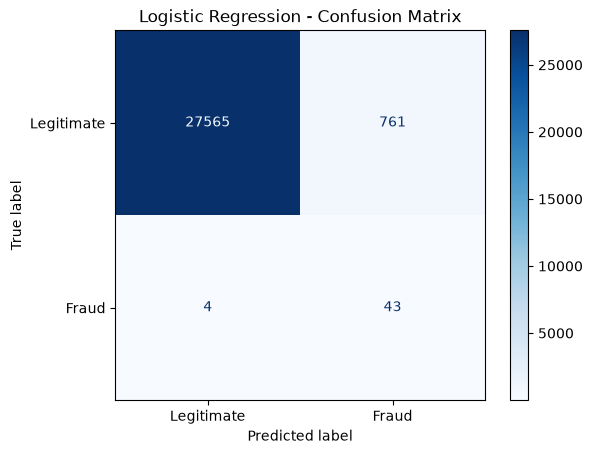

In [11]:
plt.figure(figsize=(6, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Fraud"]
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Logistic Regression - Confusion Matrix")

plt.grid(False)

plt.show()

### Confusion Matrix Analysis

The confusion matrix provides a detailed breakdown of the model's predictions.

For fraud detection, particular attention should be given to the **False Negatives**, as these represent fraudulent transactions that were incorrectly classified as legitimate. Reducing False Negatives is generally more important than maximizing overall accuracy because undetected fraud can result in significant financial loss.

The confusion matrix should always be interpreted alongside Precision, Recall, ROC-AUC, and PR-AUC to obtain a complete understanding of model performance.

## 3.3.2.7 ROC Curve

The Receiver Operating Characteristic (ROC) Curve illustrates the model's ability to distinguish between legitimate and fraudulent transactions across different classification thresholds.

The Area Under the ROC Curve (ROC-AUC) summarizes the model's ranking capability. A higher ROC-AUC indicates better discrimination between the two classes.

Although ROC-AUC is widely used, it should be interpreted together with Precision-Recall metrics for highly imbalanced datasets such as fraud detection.

In [12]:
from sklearn.metrics import RocCurveDisplay

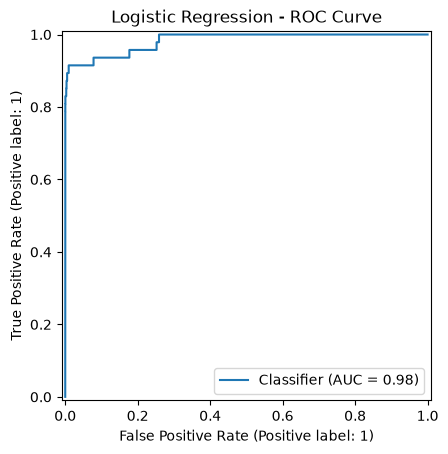

In [13]:
RocCurveDisplay.from_predictions(
    y_test_final,
    y_prob_lr
)

plt.title("Logistic Regression - ROC Curve")

plt.show()

### ROC Curve Analysis

The ROC Curve evaluates the model's ranking performance across all possible classification thresholds.

A curve closer to the upper-left corner indicates stronger discrimination between legitimate and fraudulent transactions.

While ROC-AUC is an important evaluation metric, it can sometimes present an overly optimistic view when working with highly imbalanced datasets. Therefore, Precision-Recall analysis is also required before drawing conclusions about the model's effectiveness.

## 3.3.2.8 Precision-Recall Curve

The Precision-Recall (PR) Curve evaluates the trade-off between Precision and Recall across different classification thresholds.

Unlike the ROC Curve, the PR Curve focuses only on the positive (fraud) class, making it particularly useful for highly imbalanced datasets.

The Area Under the Precision-Recall Curve (PR-AUC) summarizes the model's ability to detect fraudulent transactions while minimizing false alarms. Higher PR-AUC values indicate better performance.

In [14]:
from sklearn.metrics import PrecisionRecallDisplay

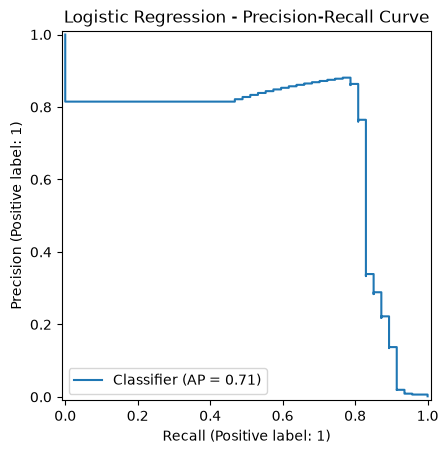

In [15]:
PrecisionRecallDisplay.from_predictions(
    y_test_final,
    y_prob_lr
)

plt.title("Logistic Regression - Precision-Recall Curve")

plt.show()

### Precision-Recall Curve Analysis

The Precision-Recall Curve provides a more informative evaluation for fraud detection than the ROC Curve because it focuses on the minority (fraud) class.

A model with a higher PR-AUC is generally better at identifying fraudulent transactions while maintaining an acceptable level of false-positive predictions.

For highly imbalanced classification problems, the PR Curve should be considered one of the primary evaluation tools when comparing different machine learning models.

## 3.3.2.9 Model Interpretation

One of the major advantages of Logistic Regression is its interpretability.

Each coefficient represents the direction and relative strength of a feature's influence on the predicted probability of fraud.

- Positive coefficients increase the likelihood of predicting fraud.
- Negative coefficients decrease the likelihood of predicting fraud.

The magnitude of the coefficient indicates the relative influence of the corresponding feature, although comparisons should primarily be made between standardized features.

In [16]:
logistic_coefficients = pd.DataFrame({
    "Feature": X_train_final.columns,
    "Coefficient": logistic_model.coef_[0]
})

logistic_coefficients["Absolute Coefficient"] = (
    logistic_coefficients["Coefficient"].abs()
)

logistic_coefficients = logistic_coefficients.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

logistic_coefficients.head(15)

,Feature,Coefficient,Absolute Coefficient
17,remainder__V14,-1.683618,1.683618
1,scaler__Amount,1.485946,1.485946
13,remainder__V10,-1.405274,1.405274
15,remainder__V12,-1.288751,1.288751
20,remainder__V17,-1.129982,1.129982
23,remainder__V20,-0.960193,0.960193
7,remainder__V4,0.951041,0.951041
25,remainder__V22,0.773477,0.773477
4,remainder__V1,0.767224,0.767224
8,remainder__V5,0.703392,0.703392


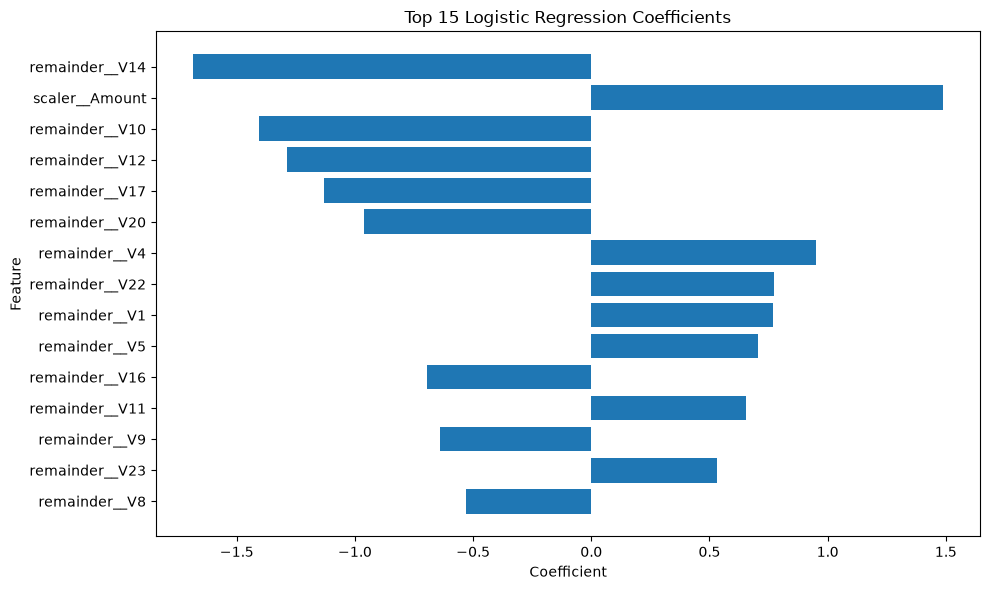

In [17]:
plt.figure(figsize=(10, 6))

top_features = logistic_coefficients.head(15)

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Top 15 Logistic Regression Coefficients")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

### Model Interpretation

The coefficient analysis identifies the features that have the strongest influence on the model's predictions.

Features with larger absolute coefficients contribute more strongly to the classification decision, while coefficients close to zero have relatively little impact.

It is important to note that Logistic Regression models only linear relationships. Therefore, more advanced models such as Random Forest and XGBoost may capture complex non-linear interactions that Logistic Regression cannot represent.

This analysis serves as a baseline for comparing feature importance across subsequent machine learning models.

## 3.3.2.10 Save Results for Comparison

To compare multiple machine learning models fairly, the evaluation metrics are stored in a centralized results table.

As additional models are trained (Random Forest, XGBoost, and LightGBM), their performance metrics will be appended to this table.

This consolidated comparison will help identify the best-performing model based on fraud detection metrics rather than relying on a single evaluation criterion.

In [18]:
logistic_results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Accuracy": [accuracy_score(y_test_final, y_pred_lr)],
    "Precision": [precision_score(y_test_final, y_pred_lr)],
    "Recall": [recall_score(y_test_final, y_pred_lr)],
    "F1-Score": [f1_score(y_test_final, y_pred_lr)],
    "ROC-AUC": [roc_auc_score(y_test_final, y_prob_lr)],
    "PR-AUC": [average_precision_score(y_test_final, y_prob_lr)]
})

logistic_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.973038,0.053483,0.914894,0.101058,0.983142,0.710773


In [19]:
model_comparison = logistic_results.copy()

model_comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.973038,0.053483,0.914894,0.101058,0.983142,0.710773


### Summary

The Logistic Regression model has been successfully trained and evaluated.

Its performance metrics have been recorded in the centralized comparison table, which will be expanded as additional machine learning models are trained.

The next phase focuses on training an ensemble learning model (Random Forest) to determine whether non-linear algorithms provide improved fraud detection performance.

# 3.3.3 Train Random Forest

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve predictive performance and reduce overfitting.

Unlike Logistic Regression, Random Forest can capture complex non-linear relationships and feature interactions without requiring explicit feature engineering.

The model is trained using the finalized SMOTE-balanced training dataset and evaluated on the untouched testing dataset using the same evaluation metrics as the baseline model.

In [20]:
from sklearn.ensemble import RandomForestClassifier

In [21]:
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

random_forest_model

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [22]:
random_forest_model.fit(
    X_train_final,
    y_train_final
)

print("✅ Random Forest model trained successfully.")

✅ Random Forest model trained successfully.


## 3.3.3.4 Generate Predictions

After training the Random Forest model, predictions are generated on the unseen testing dataset.

Two types of predictions are required:

- Predicted class labels for classification metrics.
- Predicted probabilities for threshold-independent evaluation metrics such as ROC-AUC and PR-AUC.

In [23]:
# Predicted class labels
y_pred_rf = random_forest_model.predict(X_test_final)

# Predicted probabilities
y_prob_rf = random_forest_model.predict_proba(X_test_final)[:, 1]

print("✅ Predictions generated successfully.")

✅ Predictions generated successfully.


In [24]:
print("Prediction Shape :", y_pred_rf.shape)
print("Probability Shape:", y_prob_rf.shape)

Prediction Shape : (28373,)
Probability Shape: (28373,)


## 3.3.3.5 Evaluate Performance

The Random Forest model is evaluated using the same performance metrics as the Logistic Regression baseline.

Using identical evaluation metrics ensures a fair comparison between different machine learning models.

The evaluation includes:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC
- PR-AUC

In [25]:
random_forest_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "PR-AUC"
    ],
    "Value": [
        accuracy_score(y_test_final, y_pred_rf),
        precision_score(y_test_final, y_pred_rf),
        recall_score(y_test_final, y_pred_rf),
        f1_score(y_test_final, y_pred_rf),
        roc_auc_score(y_test_final, y_prob_rf),
        average_precision_score(y_test_final, y_prob_rf)
    ]
})

random_forest_metrics

,Metric,Value
0,Accuracy,0.999436
1,Precision,0.878049
2,Recall,0.765957
3,F1-Score,0.818182
4,ROC-AUC,0.961347
5,PR-AUC,0.833193


### Performance Analysis

The evaluation metrics summarize the Random Forest model's predictive performance on the unseen testing dataset.

These results will later be compared with Logistic Regression, XGBoost, and LightGBM to identify the most effective model for fraud detection.

For imbalanced classification problems, Recall, PR-AUC, and F1-Score are generally more informative than Accuracy alone because they better reflect the model's ability to identify fraudulent transactions.

## 3.3.3.6 Confusion Matrix

The confusion matrix summarizes the classification performance of the Random Forest model by comparing predicted labels with the actual labels.

It reports:

- True Positives (TP)
- True Negatives (TN)
- False Positives (FP)
- False Negatives (FN)

For fraud detection, minimizing False Negatives is particularly important because undetected fraudulent transactions may lead to financial loss.

In [26]:
cm_rf = confusion_matrix(
    y_test_final,
    y_pred_rf
)

cm_rf

array([[28321,     5],
       [   11,    36]])

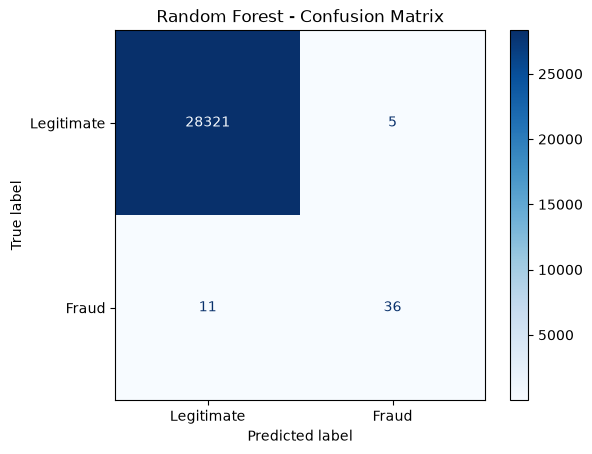

In [27]:
ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Legitimate", "Fraud"]
).plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Random Forest - Confusion Matrix")

plt.grid(False)

plt.show()

### Confusion Matrix Analysis

The confusion matrix provides a detailed breakdown of the Random Forest model's predictions.

Compared with Logistic Regression, this visualization helps determine whether the ensemble model reduces False Negatives while maintaining acceptable Precision.

The confusion matrix should always be interpreted alongside Precision, Recall, ROC-AUC, and PR-AUC for a comprehensive evaluation of fraud detection performance.

## 3.3.3.7 ROC Curve

The Receiver Operating Characteristic (ROC) Curve illustrates the Random Forest model's ability to distinguish between legitimate and fraudulent transactions across different classification thresholds.

The Area Under the ROC Curve (ROC-AUC) summarizes the model's ranking performance. A higher ROC-AUC indicates better discrimination between the two classes.

The ROC Curve is useful for comparing classification models, although it should be interpreted together with the Precision-Recall Curve for highly imbalanced datasets.

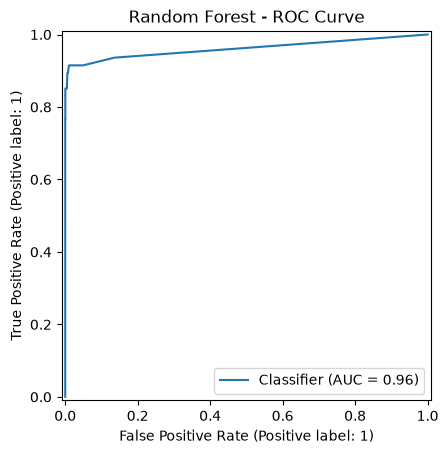

In [28]:
RocCurveDisplay.from_predictions(
    y_test_final,
    y_prob_rf
)

plt.title("Random Forest - ROC Curve")

plt.show()

### ROC Curve Analysis

The ROC Curve evaluates the Random Forest model's ability to distinguish fraudulent transactions from legitimate ones across different decision thresholds.

A curve closer to the upper-left corner indicates stronger classification performance.

Although ROC-AUC is a valuable metric, it should not be used in isolation for imbalanced datasets. The Precision-Recall Curve provides additional insight into the model's effectiveness in identifying the minority fraud class.

## 3.3.3.8 Precision-Recall Curve

The Precision-Recall (PR) Curve illustrates the trade-off between Precision and Recall across different classification thresholds.

Unlike the ROC Curve, the PR Curve focuses specifically on the minority (fraud) class, making it particularly valuable for highly imbalanced classification problems.

The Area Under the Precision-Recall Curve (PR-AUC) summarizes the model's effectiveness in identifying fraudulent transactions while minimizing false-positive predictions.

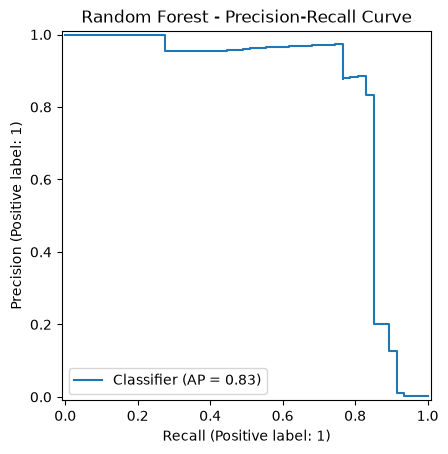

In [29]:
PrecisionRecallDisplay.from_predictions(
    y_test_final,
    y_prob_rf
)

plt.title("Random Forest - Precision-Recall Curve")

plt.show()

### Precision-Recall Curve Analysis

The Precision-Recall Curve provides a more informative evaluation of the Random Forest model than the ROC Curve for fraud detection.

A higher PR-AUC indicates that the model maintains strong Recall while minimizing False Positives, which is desirable when identifying rare fraudulent transactions.

This visualization will later be compared with Logistic Regression, XGBoost, and LightGBM to determine which model best balances fraud detection performance and prediction reliability.

## 3.3.3.9 Feature Importance

Unlike Logistic Regression, Random Forest does not provide interpretable coefficients. Instead, it estimates the relative importance of each feature based on its contribution to reducing impurity across all decision trees.

Feature Importance helps identify which variables have the greatest influence on the model's predictions and provides valuable insights into the underlying patterns learned during training.

This analysis also improves model interpretability and supports feature engineering decisions in future iterations.

In [30]:
random_forest_importance = pd.DataFrame({
    "Feature": X_train_final.columns,
    "Importance": random_forest_model.feature_importances_
})

random_forest_importance = random_forest_importance.sort_values(
    by="Importance",
    ascending=False
)

random_forest_importance.head(15)

,Feature,Importance
17,remainder__V14,0.211976
13,remainder__V10,0.149324
15,remainder__V12,0.095969
20,remainder__V17,0.084127
7,remainder__V4,0.083984
14,remainder__V11,0.059675
6,remainder__V3,0.044275
19,remainder__V16,0.039753
10,remainder__V7,0.031401
5,remainder__V2,0.018105


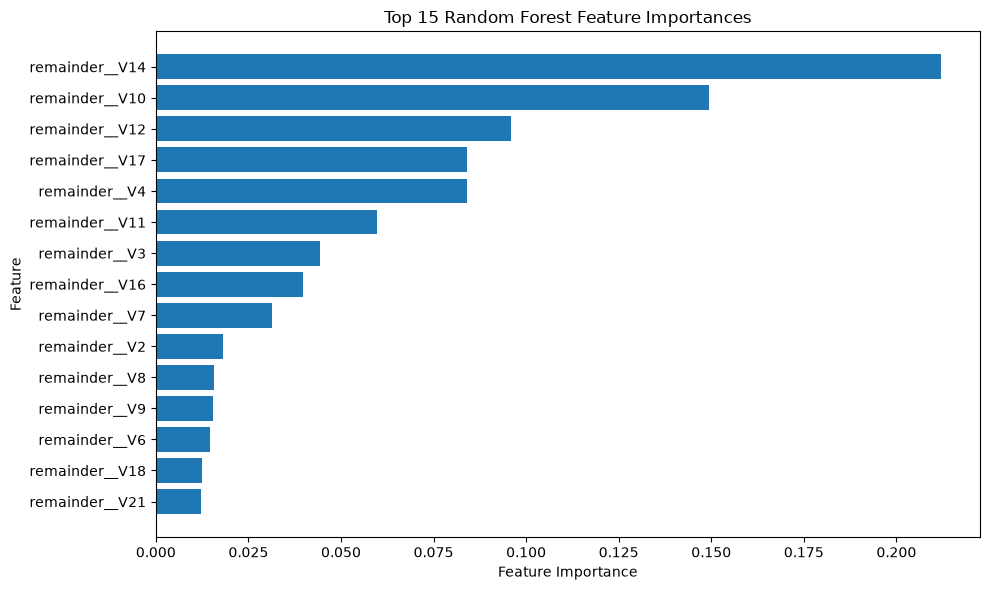

In [31]:
plt.figure(figsize=(10, 6))

top_features = random_forest_importance.head(15)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Feature Importances")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

### Feature Importance Analysis

The feature importance analysis highlights the variables that contribute most to the Random Forest model's predictions.

Features with higher importance values have a greater influence on the model's decision-making process, while features with lower importance contribute relatively less.

Unlike Logistic Regression coefficients, feature importance values indicate relative influence only and do not describe whether a feature increases or decreases the probability of fraud.

The identified important features can guide future feature engineering and provide insights into the characteristics associated with fraudulent transactions.

## 3.3.3.10 Save Results for Comparison

The evaluation metrics of the Random Forest model are appended to the centralized model comparison table.

Maintaining a unified comparison table enables an objective evaluation of all machine learning models trained throughout the project.

As additional models are developed, their evaluation metrics will also be added to this table, allowing a comprehensive comparison before selecting the final production model.

In [32]:
random_forest_results = pd.DataFrame({
    "Model": ["Random Forest"],
    "Accuracy": [accuracy_score(y_test_final, y_pred_rf)],
    "Precision": [precision_score(y_test_final, y_pred_rf)],
    "Recall": [recall_score(y_test_final, y_pred_rf)],
    "F1-Score": [f1_score(y_test_final, y_pred_rf)],
    "ROC-AUC": [roc_auc_score(y_test_final, y_prob_rf)],
    "PR-AUC": [average_precision_score(y_test_final, y_prob_rf)]
})

random_forest_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Random Forest,0.999436,0.878049,0.765957,0.818182,0.961347,0.833193


In [33]:
model_comparison = pd.concat(
    [
        model_comparison,
        random_forest_results
    ],
    ignore_index=True
)

model_comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.973038,0.053483,0.914894,0.101058,0.983142,0.710773
1,Random Forest,0.999436,0.878049,0.765957,0.818182,0.961347,0.833193


### Summary

The Random Forest model has been successfully trained, evaluated, and compared with the Logistic Regression baseline.

Its evaluation metrics have been added to the centralized comparison table, providing a consistent framework for benchmarking all subsequent machine learning models.

The next stage focuses on training XGBoost, a gradient boosting algorithm that often achieves state-of-the-art performance in structured tabular datasets, including fraud detection.

# 3.3.4 Train XGBoost

XGBoost (Extreme Gradient Boosting) is one of the most powerful machine learning algorithms for structured tabular data.

It builds an ensemble of decision trees sequentially, where each new tree attempts to correct the errors made by previous trees. This boosting strategy often results in superior predictive performance compared to traditional ensemble methods.

XGBoost is widely used in fraud detection, credit risk assessment, recommendation systems, and numerous machine learning competitions due to its speed, scalability, and high predictive accuracy.

The model is trained using the finalized SMOTE-balanced training dataset and evaluated on the untouched testing dataset using the same evaluation pipeline as the previous models.

In [34]:
from xgboost import XGBClassifier

In [35]:
xgboost_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric="logloss"
)

xgboost_model

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [36]:
xgboost_model.fit(
    X_train_final,
    y_train_final
)

print("✅ XGBoost model trained successfully.")

✅ XGBoost model trained successfully.


## 3.3.4.4 Generate Predictions

After training the XGBoost model, predictions are generated on the unseen testing dataset.

Two types of predictions are required:

- Predicted class labels for calculating classification metrics.
- Predicted probabilities for threshold-independent evaluation metrics such as ROC-AUC and PR-AUC.

In [37]:
# Predicted class labels
y_pred_xgb = xgboost_model.predict(X_test_final)

# Predicted probabilities
y_prob_xgb = xgboost_model.predict_proba(X_test_final)[:, 1]

print("✅ Predictions generated successfully.")

✅ Predictions generated successfully.


In [38]:
print("Prediction Shape :", y_pred_xgb.shape)
print("Probability Shape:", y_prob_xgb.shape)

Prediction Shape : (28373,)
Probability Shape: (28373,)


## 3.3.4.5 Evaluate Performance

The XGBoost model is evaluated using the same performance metrics as the previous machine learning models.

Using identical evaluation criteria ensures a fair and objective comparison between Logistic Regression, Random Forest, and XGBoost.

The evaluation includes:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC
- PR-AUC

In [39]:
xgboost_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "PR-AUC"
    ],
    "Value": [
        accuracy_score(y_test_final, y_pred_xgb),
        precision_score(y_test_final, y_pred_xgb),
        recall_score(y_test_final, y_pred_xgb),
        f1_score(y_test_final, y_pred_xgb),
        roc_auc_score(y_test_final, y_prob_xgb),
        average_precision_score(y_test_final, y_prob_xgb)
    ]
})

xgboost_metrics

,Metric,Value
0,Accuracy,0.997780
1,Precision,0.416667
2,Recall,0.851064
3,F1-Score,0.559441
4,ROC-AUC,0.983940
5,PR-AUC,0.829751


### Performance Analysis

The evaluation metrics summarize the predictive performance of the XGBoost model on the unseen testing dataset.

These results will later be compared with Logistic Regression and Random Forest using the centralized model comparison table.

For fraud detection, Recall, PR-AUC, and F1-Score are particularly important because they better reflect the model's ability to detect rare fraudulent transactions while balancing false-positive predictions.

## 3.3.4.6 Confusion Matrix

The confusion matrix summarizes the classification performance of the XGBoost model by comparing predicted labels with the actual labels.

It reports:

- True Positives (TP)
- True Negatives (TN)
- False Positives (FP)
- False Negatives (FN)

For fraud detection, reducing False Negatives is especially important because undetected fraudulent transactions can lead to significant financial loss.

In [40]:
cm_xgb = confusion_matrix(
    y_test_final,
    y_pred_xgb
)

cm_xgb

array([[28270,    56],
       [    7,    40]])

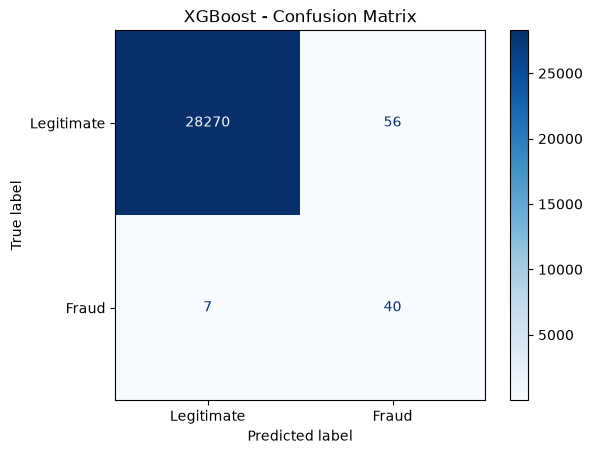

In [41]:
ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=["Legitimate", "Fraud"]
).plot(
    cmap="Blues",
    values_format="d"
)

plt.title("XGBoost - Confusion Matrix")

plt.grid(False)

plt.show()

### Confusion Matrix Analysis

The confusion matrix provides a detailed view of the XGBoost model's classification performance.

Particular attention should be given to False Negatives, as these represent fraudulent transactions that were incorrectly classified as legitimate.

This visualization complements Precision, Recall, ROC-AUC, and PR-AUC, providing a comprehensive understanding of the model's strengths and weaknesses before comparing it with other machine learning models.

## 3.3.4.7 ROC Curve

The Receiver Operating Characteristic (ROC) Curve illustrates the XGBoost model's ability to distinguish between legitimate and fraudulent transactions across different classification thresholds.

The Area Under the ROC Curve (ROC-AUC) summarizes the model's ranking performance. A higher ROC-AUC indicates better discrimination between the two classes.

Although ROC-AUC is a valuable evaluation metric, it should always be interpreted alongside the Precision-Recall Curve when working with highly imbalanced datasets such as fraud detection.

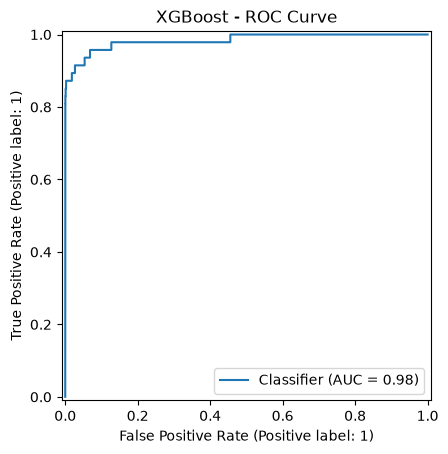

In [42]:
RocCurveDisplay.from_predictions(
    y_test_final,
    y_prob_xgb
)

plt.title("XGBoost - ROC Curve")

plt.show()

### ROC Curve Analysis

The ROC Curve evaluates the XGBoost model's ability to distinguish fraudulent transactions from legitimate ones across all possible decision thresholds.

A curve closer to the upper-left corner indicates stronger classification performance and better ranking capability.

While ROC-AUC provides an overall assessment of discrimination ability, it should be interpreted together with the Precision-Recall Curve to accurately evaluate performance on highly imbalanced fraud detection datasets.

## 3.3.4.8 Precision-Recall Curve

The Precision-Recall (PR) Curve illustrates the trade-off between Precision and Recall across different classification thresholds.

Unlike the ROC Curve, the PR Curve focuses specifically on the minority (fraud) class, making it a more informative evaluation tool for highly imbalanced datasets.

The Area Under the Precision-Recall Curve (PR-AUC) summarizes the model's ability to identify fraudulent transactions while minimizing false-positive predictions.

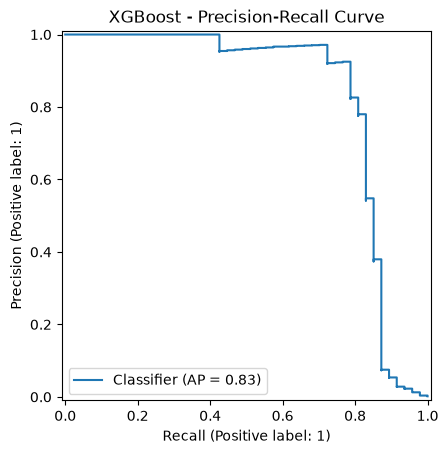

In [43]:
PrecisionRecallDisplay.from_predictions(
    y_test_final,
    y_prob_xgb
)

plt.title("XGBoost - Precision-Recall Curve")

plt.show()

### Precision-Recall Curve Analysis

The Precision-Recall Curve provides a focused evaluation of the XGBoost model's performance on the fraud class.

A higher PR-AUC indicates that the model maintains strong Recall while achieving high Precision, which is especially desirable in fraud detection applications where fraudulent transactions are rare.

This visualization will later be compared with Logistic Regression and Random Forest to determine which model provides the best balance between fraud detection capability and prediction reliability.

## 3.3.4.9 Feature Importance

XGBoost estimates feature importance by measuring the contribution of each feature to the ensemble of boosted decision trees.

Features with higher importance values contribute more significantly to the model's predictive performance.

Feature importance analysis improves model interpretability, helps identify the most influential variables, and provides valuable insights for future feature engineering and model optimization.

In [44]:
xgboost_importance = pd.DataFrame({
    "Feature": X_train_final.columns,
    "Importance": xgboost_model.feature_importances_
})

xgboost_importance = xgboost_importance.sort_values(
    by="Importance",
    ascending=False
)

xgboost_importance.head(15)

,Feature,Importance
17,remainder__V14,0.525376
7,remainder__V4,0.044646
11,remainder__V8,0.030178
1,scaler__Amount,0.024343
15,remainder__V12,0.022818
13,remainder__V10,0.021918
21,remainder__V18,0.021727
16,remainder__V13,0.021571
26,remainder__V23,0.020128
2,scaler__TransactionHour,0.020105


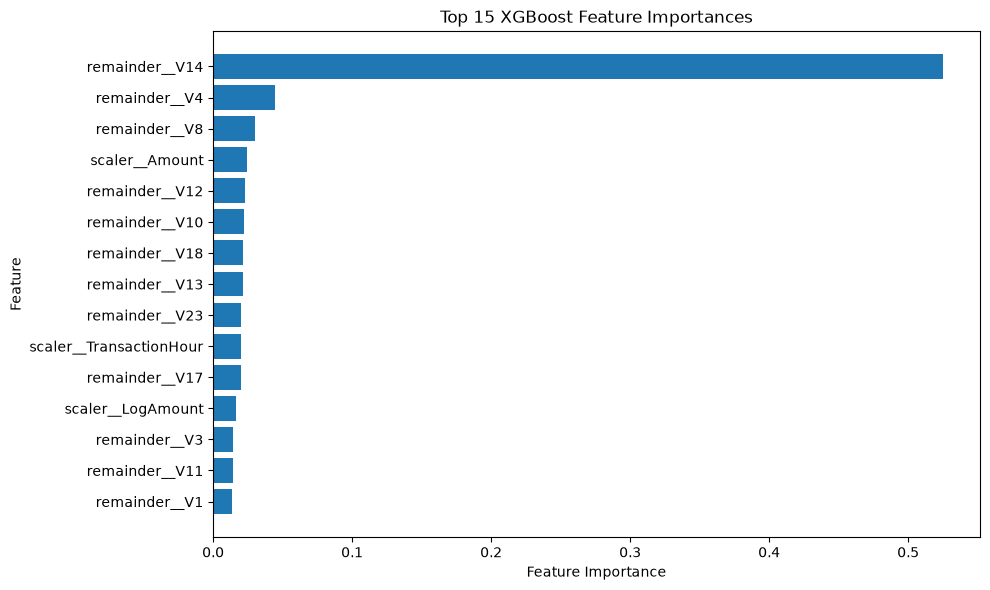

In [45]:
plt.figure(figsize=(10, 6))

top_features = xgboost_importance.head(15)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 XGBoost Feature Importances")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

### Feature Importance Analysis

The feature importance analysis identifies the variables that contribute most to the XGBoost model's predictions.

Features with higher importance scores have a greater influence on the model's decision-making process, while features with lower scores contribute relatively less.

Unlike Logistic Regression, XGBoost feature importance values indicate the relative contribution of each feature but do not indicate whether a feature increases or decreases the probability of fraud.

Comparing feature importance across Random Forest and XGBoost provides additional insight into which variables consistently influence fraud detection.

## 3.3.4.10 Save Results for Comparison

The evaluation metrics of the XGBoost model are appended to the centralized model comparison table.

Maintaining a unified comparison table enables an objective comparison of all machine learning models developed during this project.

This consolidated table will serve as the foundation for selecting the best-performing model for deployment.

In [46]:
xgboost_results = pd.DataFrame({
    "Model": ["XGBoost"],
    "Accuracy": [accuracy_score(y_test_final, y_pred_xgb)],
    "Precision": [precision_score(y_test_final, y_pred_xgb)],
    "Recall": [recall_score(y_test_final, y_pred_xgb)],
    "F1-Score": [f1_score(y_test_final, y_pred_xgb)],
    "ROC-AUC": [roc_auc_score(y_test_final, y_prob_xgb)],
    "PR-AUC": [average_precision_score(y_test_final, y_prob_xgb)]
})

xgboost_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,XGBoost,0.99778,0.416667,0.851064,0.559441,0.98394,0.829751


In [47]:
model_comparison = pd.concat(
    [
        model_comparison,
        xgboost_results
    ],
    ignore_index=True
)

model_comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.973038,0.053483,0.914894,0.101058,0.983142,0.710773
1,Random Forest,0.999436,0.878049,0.765957,0.818182,0.961347,0.833193
2,XGBoost,0.997780,0.416667,0.851064,0.559441,0.983940,0.829751


### Summary

The XGBoost model has been successfully trained, evaluated, and compared with the previously developed models.

Its evaluation metrics have been appended to the centralized comparison table, enabling a consistent benchmark across all classifiers.

At this stage, the project includes three trained models:

- Logistic Regression
- Random Forest
- XGBoost

The next phase introduces LightGBM as an optional high-performance gradient boosting model for additional benchmarking.

# 3.3.5 Train LightGBM

LightGBM (Light Gradient Boosting Machine) is a high-performance gradient boosting framework designed for speed, efficiency, and scalability.

Compared to traditional gradient boosting methods, LightGBM uses histogram-based learning and leaf-wise tree growth, enabling faster training while maintaining high predictive performance.

Because of its excellent performance on structured/tabular datasets, LightGBM is widely adopted in real-world machine learning competitions and production systems.

In this section, the LightGBM classifier will be trained using the same standardized evaluation pipeline applied to the previous models, ensuring a fair comparison across all classifiers.

## 3.3.5.1 Import Library

In [48]:
from lightgbm import LGBMClassifier

The LightGBM classifier has been imported successfully and is now available for model training.

## 3.3.5.2 Initialize Model

The LightGBM classifier is initialized using a baseline configuration.

These hyperparameters provide a strong starting point for model training while maintaining consistency with the baseline configurations used for the previous machine learning models.

Hyperparameter optimization will be performed in a later phase if required.

In [49]:
lightgbm_model = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    verbose=-1
)

lightgbm_model

,max_depth,6
,random_state,42
,verbose,-1
,boosting_type,'gbdt'
,num_leaves,31
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0


The LightGBM model has been successfully initialized and is ready for training using the processed training dataset.

## 3.3.5.3 Train Model

The LightGBM classifier is trained using the processed training dataset.

During training, the model learns patterns that distinguish legitimate transactions from fraudulent ones by constructing an ensemble of gradient-boosted decision trees.

The trained model will be used in the subsequent steps for prediction, evaluation, and comparison with the other machine learning models.

In [50]:
lightgbm_model.fit(
    X_train_final,
    y_train_final
)

,max_depth,6
,random_state,42
,verbose,-1
,boosting_type,'gbdt'
,num_leaves,31
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0


The LightGBM model has been successfully trained and is now ready to generate predictions on the unseen test dataset.

## 3.3.5.4 Generate Predictions

After training, the LightGBM model is used to generate predictions on the unseen test dataset.

Two types of predictions are produced:

- Predicted class labels for performance evaluation.
- Predicted probabilities for threshold-independent evaluation metrics such as ROC-AUC and PR-AUC.

These outputs will be used in the subsequent evaluation and comparison steps.

In [51]:
y_pred_lgbm = lightgbm_model.predict(
    X_test_final
)

y_prob_lgbm = lightgbm_model.predict_proba(
    X_test_final
)[:, 1]

The LightGBM model has successfully generated both class predictions and probability scores for the test dataset.

These predictions will be used to evaluate classification performance using multiple metrics and visualizations.

## 3.3.5.5 Evaluate Performance

The trained LightGBM model is evaluated using multiple classification metrics to measure its predictive performance.

The evaluation includes:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC
- PR-AUC

Using a standardized evaluation framework ensures a fair comparison with Logistic Regression, Random Forest, and XGBoost.

In [52]:
lightgbm_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "PR-AUC"
    ],
    "Value": [
        accuracy_score(y_test_final, y_pred_lgbm),
        precision_score(y_test_final, y_pred_lgbm),
        recall_score(y_test_final, y_pred_lgbm),
        f1_score(y_test_final, y_pred_lgbm),
        roc_auc_score(y_test_final, y_prob_lgbm),
        average_precision_score(y_test_final, y_prob_lgbm)
    ]
})

lightgbm_metrics

,Metric,Value
0,Accuracy,0.997286
1,Precision,0.363636
2,Recall,0.851064
3,F1-Score,0.509554
4,ROC-AUC,0.981087
5,PR-AUC,0.805852


### Performance Evaluation

The evaluation metrics summarize the predictive performance of the LightGBM classifier on the unseen test dataset.

Since fraud detection is an imbalanced classification problem, particular attention should be given to Precision, Recall, F1-Score, ROC-AUC, and PR-AUC rather than relying solely on Accuracy.

The computed metrics will later be compared with the other machine learning models to identify the most suitable classifier for deployment.

## 3.3.5.6 Confusion Matrix

The confusion matrix summarizes the classification performance of the LightGBM model by comparing predicted labels with the actual labels.

It reports:

- True Positives (TP)
- True Negatives (TN)
- False Positives (FP)
- False Negatives (FN)

For fraud detection, minimizing False Negatives is particularly important because undetected fraudulent transactions can lead to significant financial losses.

In [53]:
cm_lgbm = confusion_matrix(
    y_test_final,
    y_pred_lgbm
)

cm_lgbm

array([[28256,    70],
       [    7,    40]])

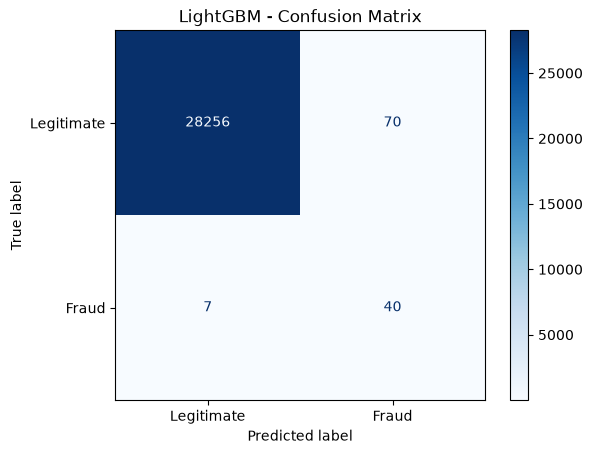

In [54]:
ConfusionMatrixDisplay(
    confusion_matrix=cm_lgbm,
    display_labels=["Legitimate", "Fraud"]
).plot(
    cmap="Blues",
    values_format="d"
)

plt.title("LightGBM - Confusion Matrix")

plt.grid(False)

plt.show()

### Confusion Matrix Analysis

The confusion matrix provides a detailed view of the LightGBM model's classification performance.

Special attention should be given to False Negatives, as these represent fraudulent transactions incorrectly classified as legitimate.

This visualization complements Precision, Recall, ROC-AUC, and PR-AUC, providing a comprehensive assessment of the model before comparing it with the other classifiers.

## 3.3.5.7 ROC Curve

The Receiver Operating Characteristic (ROC) Curve illustrates the LightGBM model's ability to distinguish between legitimate and fraudulent transactions across different classification thresholds.

The Area Under the ROC Curve (ROC-AUC) summarizes the model's ranking performance. A higher ROC-AUC indicates better discrimination between the two classes.

Although ROC-AUC is an important evaluation metric, it should always be interpreted alongside the Precision-Recall Curve when working with highly imbalanced datasets such as fraud detection.

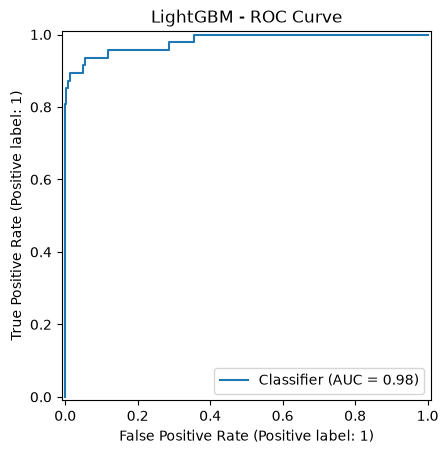

In [55]:
RocCurveDisplay.from_predictions(
    y_test_final,
    y_prob_lgbm
)

plt.title("LightGBM - ROC Curve")

plt.show()

### ROC Curve Analysis

The ROC Curve evaluates the LightGBM model's ability to distinguish fraudulent transactions from legitimate ones across all classification thresholds.

A curve closer to the upper-left corner indicates stronger classification performance.

Since fraud detection datasets are highly imbalanced, ROC-AUC should be interpreted together with the Precision-Recall Curve.

## 3.3.5.8 Precision-Recall Curve

The Precision-Recall Curve illustrates the trade-off between Precision and Recall across different classification thresholds.

Unlike the ROC Curve, the PR Curve focuses specifically on the fraud class, making it more informative for highly imbalanced datasets.

The Area Under the Precision-Recall Curve (PR-AUC) summarizes the model's effectiveness in identifying fraudulent transactions while minimizing false positives.

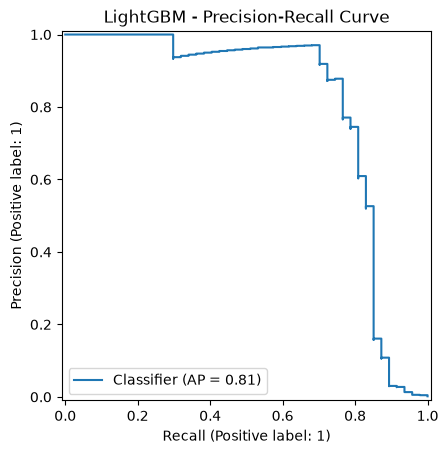

In [56]:
PrecisionRecallDisplay.from_predictions(
    y_test_final,
    y_prob_lgbm
)

plt.title("LightGBM - Precision-Recall Curve")

plt.show()

### Precision-Recall Curve Analysis

The Precision-Recall Curve provides a focused evaluation of the LightGBM model's performance on the minority fraud class.

A higher PR-AUC indicates that the model maintains strong Recall while preserving high Precision, making it well-suited for fraud detection applications.

This visualization will later be compared with Logistic Regression, Random Forest, and XGBoost.

## 3.3.5.9 Feature Importance

LightGBM estimates feature importance based on the contribution of each feature during gradient boosting.

Features with larger importance values contribute more significantly to the prediction process.

Feature importance analysis improves model interpretability and helps identify the variables most associated with fraudulent transactions.

In [57]:
lightgbm_importance = pd.DataFrame({
    "Feature": X_train_final.columns,
    "Importance": lightgbm_model.feature_importances_
})

lightgbm_importance = lightgbm_importance.sort_values(
    by="Importance",
    ascending=False
)

lightgbm_importance.head(15)

,Feature,Importance
17,remainder__V14,270
7,remainder__V4,209
15,remainder__V12,183
4,remainder__V1,149
13,remainder__V10,131
10,remainder__V7,125
11,remainder__V8,121
20,remainder__V17,119
6,remainder__V3,119
14,remainder__V11,98


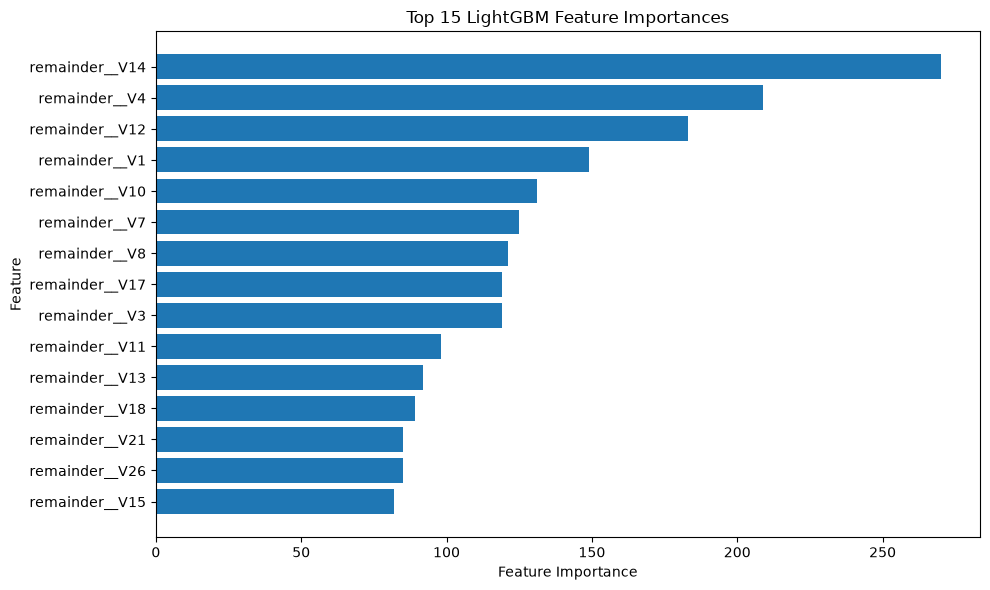

In [58]:
plt.figure(figsize=(10, 6))

top_features = lightgbm_importance.head(15)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 LightGBM Feature Importances")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

### Feature Importance Analysis

The feature importance analysis identifies the variables that contribute most to the LightGBM model's predictions.

Higher importance scores indicate stronger influence on the model's decision-making process.

Comparing feature importance across Random Forest, XGBoost, and LightGBM provides additional insight into which variables consistently influence fraud detection.

## 3.3.5.10 Save Results for Comparison

The evaluation metrics of the LightGBM classifier are appended to the centralized model comparison table.

Maintaining a unified comparison table enables an objective comparison of all machine learning models developed during this project.

This table will serve as the basis for selecting the final deployment model.

In [59]:
lightgbm_results = pd.DataFrame({
    "Model": ["LightGBM"],
    "Accuracy": [accuracy_score(y_test_final, y_pred_lgbm)],
    "Precision": [precision_score(y_test_final, y_pred_lgbm)],
    "Recall": [recall_score(y_test_final, y_pred_lgbm)],
    "F1-Score": [f1_score(y_test_final, y_pred_lgbm)],
    "ROC-AUC": [roc_auc_score(y_test_final, y_prob_lgbm)],
    "PR-AUC": [average_precision_score(y_test_final, y_prob_lgbm)]
})

lightgbm_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,LightGBM,0.997286,0.363636,0.851064,0.509554,0.981087,0.805852


In [60]:
model_comparison = pd.concat(
    [
        model_comparison,
        lightgbm_results
    ],
    ignore_index=True
)

model_comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.973038,0.053483,0.914894,0.101058,0.983142,0.710773
1,Random Forest,0.999436,0.878049,0.765957,0.818182,0.961347,0.833193
2,XGBoost,0.997780,0.416667,0.851064,0.559441,0.983940,0.829751
3,LightGBM,0.997286,0.363636,0.851064,0.509554,0.981087,0.805852


### LightGBM Summary

The LightGBM classifier has been successfully trained, evaluated, and benchmarked against the previously developed models.

Its performance metrics have been added to the centralized comparison table, completing the baseline evaluation of four machine learning classifiers:

- Logistic Regression
- Random Forest
- XGBoost
- LightGBM

The next phase focuses on comparing these models and selecting the most suitable candidate for deployment.

# 3.3.6 Training Summary & Model Comparison

Four baseline machine learning models have now been trained and evaluated using an identical workflow.

The objective of this phase is to compare their performance, identify the strengths and weaknesses of each algorithm, and select the most appropriate model for fraud detection.

A standardized evaluation framework ensures that the comparison is objective, reproducible, and suitable for deployment decisions.

## 3.3.6.1 Final Model Comparison Table

In [61]:
model_comparison = model_comparison.sort_values(
    by="PR-AUC",
    ascending=False
).reset_index(drop=True)

model_comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Random Forest,0.999436,0.878049,0.765957,0.818182,0.961347,0.833193
1,XGBoost,0.997780,0.416667,0.851064,0.559441,0.983940,0.829751
2,LightGBM,0.997286,0.363636,0.851064,0.509554,0.981087,0.805852
3,Logistic Regression,0.973038,0.053483,0.914894,0.101058,0.983142,0.710773


The comparison table summarizes the performance of all trained machine learning models using standardized evaluation metrics.

Since fraud detection is an imbalanced classification problem, PR-AUC and Recall are considered more informative than Accuracy alone.

## 3.3.6.2 Best Model by Each Metric

In [62]:
best_models = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "PR-AUC"
    ],
    "Best Model": [
        model_comparison.loc[model_comparison["Accuracy"].idxmax(), "Model"],
        model_comparison.loc[model_comparison["Precision"].idxmax(), "Model"],
        model_comparison.loc[model_comparison["Recall"].idxmax(), "Model"],
        model_comparison.loc[model_comparison["F1-Score"].idxmax(), "Model"],
        model_comparison.loc[model_comparison["ROC-AUC"].idxmax(), "Model"],
        model_comparison.loc[model_comparison["PR-AUC"].idxmax(), "Model"]
    ]
})

best_models

,Metric,Best Model
0,Accuracy,Random Forest
1,Precision,Random Forest
2,Recall,Logistic Regression
3,F1-Score,Random Forest
4,ROC-AUC,XGBoost
5,PR-AUC,Random Forest


The table above highlights which machine learning model achieved the highest score for each evaluation metric.

This comparison demonstrates that no single metric should be used in isolation when selecting a model for deployment.

## 3.3.6.3 Overall Performance Ranking

In [63]:
model_comparison.style.highlight_max(
    subset=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "PR-AUC"
    ],
    color="lightgreen"
)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Random Forest,0.999436,0.878049,0.765957,0.818182,0.961347,0.833193
1,XGBoost,0.997780,0.416667,0.851064,0.559441,0.983940,0.829751
2,LightGBM,0.997286,0.363636,0.851064,0.509554,0.981087,0.805852
3,Logistic Regression,0.973038,0.053483,0.914894,0.101058,0.983142,0.710773


The highlighted comparison table provides a visual overview of the strongest-performing model for each evaluation metric, making it easier to identify consistent high-performing algorithms.

## 3.3.6.4 Strengths and Limitations

| Model | Strengths | Limitations |
|-------|-----------|-------------|
| Logistic Regression | Fast, interpretable, simple | Limited ability to capture nonlinear relationships |
| Random Forest | Robust, interpretable feature importance | Larger model size and slower inference |
| XGBoost | Excellent predictive performance, highly optimized | More hyperparameters and longer training time |
| LightGBM | Very fast training, strong performance, efficient memory usage | Sensitive to hyperparameter tuning on some datasets |

## 3.3.6.5 Final Model Selection Strategy

The final deployment model should not be selected solely based on Accuracy.

Instead, greater emphasis should be placed on:

- PR-AUC
- Recall
- F1-Score
- ROC-AUC

These metrics better reflect real-world fraud detection performance where fraudulent transactions are significantly less frequent than legitimate ones.

The model achieving the best balance across these metrics will be selected for deployment in later phases.

## 3.3.6.6 Summary of Findings

The comparative evaluation demonstrates that ensemble-based gradient boosting algorithms generally outperform the simpler baseline model.

However, the final deployment decision will be based on a comprehensive evaluation rather than a single performance metric.

Additional hyperparameter tuning and validation will be performed before selecting the production-ready model.

## 3.3.6.7 Conclusion

All four baseline machine learning models have now been successfully trained, evaluated, and benchmarked.

The project now has a reliable foundation for model optimization, hyperparameter tuning, explainability, and deployment.

## 3.3.6.8 Transition to Hyperparameter Tuning

The next phase focuses on improving the performance of the selected baseline models through systematic hyperparameter optimization.

Rather than training new algorithms, the objective will be to maximize predictive performance while maintaining generalization on unseen data.

# Training Summary

After training Logistic Regression, Random Forest, XGBoost, and LightGBM, a standardized comparison was performed using Accuracy, Precision, Recall, F1-Score, ROC-AUC, and PR-AUC.

The comparison highlighted the strengths and limitations of each algorithm and established a consistent framework for selecting the most suitable model for deployment.

Given the imbalanced nature of fraud detection, PR-AUC, Recall, and F1-Score will receive greater emphasis than Accuracy during final model selection.

The project now proceeds to model optimization through hyperparameter tuning.

# 3.4 Hyperparameter Tuning

The baseline evaluation established the performance of four machine learning models.

The objective of this phase is to improve predictive performance by optimizing the hyperparameters of the strongest-performing ensemble models.

Unlike baseline training, hyperparameter tuning systematically searches for better parameter combinations while maintaining good generalization on unseen data.

Only the ensemble-based models (Random Forest, XGBoost, and LightGBM) will be tuned, while Logistic Regression will remain the baseline reference model.

## 3.4.1 Define Search Space

Before performing hyperparameter optimization, an appropriate search space must be defined for each model.

The search space specifies the range of candidate values that the optimization algorithm will evaluate.

A well-designed search space balances computational efficiency with the likelihood of discovering high-performing parameter combinations.

### Hyperparameter Tuning Strategy

The following optimization techniques will be used during this phase:

- Cross Validation for robust model evaluation.
- Randomized Search for efficient exploration of large parameter spaces.
- Grid Search (optional refinement) around the best-performing parameter combinations.

This two-stage strategy provides a good balance between computational cost and model performance.

In [64]:
from sklearn.model_selection import (
    RandomizedSearchCV,
    GridSearchCV,
    StratifiedKFold
)

The required hyperparameter optimization utilities have been imported successfully.

These utilities will be reused throughout the tuning process for all ensemble models.

In [65]:
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_strategy

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

A 5-fold stratified cross-validation strategy has been configured.

Stratification preserves the original fraud-to-legitimate class distribution in every fold, ensuring a reliable evaluation for this imbalanced classification problem.

### Random Forest Search Space

In [66]:
random_forest_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

random_forest_param_grid

{'n_estimators': [100, 200, 300],
 'max_depth': [None, 10, 20, 30],
 'min_samples_split': [2, 5, 10],
 'min_samples_leaf': [1, 2, 4],
 'max_features': ['sqrt', 'log2']}

### XGBoost Search Space

In [67]:
xgboost_param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgboost_param_grid

{'n_estimators': [100, 200, 300],
 'learning_rate': [0.01, 0.05, 0.1],
 'max_depth': [3, 5, 7],
 'subsample': [0.8, 1.0],
 'colsample_bytree': [0.8, 1.0]}

### LightGBM Search Space

In [68]:
lightgbm_param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "num_leaves": [31, 63, 127],
    "subsample": [0.8, 1.0]
}

lightgbm_param_grid

{'n_estimators': [100, 200, 300],
 'learning_rate': [0.01, 0.05, 0.1],
 'max_depth': [3, 5, 7],
 'num_leaves': [31, 63, 127],
 'subsample': [0.8, 1.0]}

## 3.4.2 Cross Validation

Cross Validation is a resampling technique used to estimate how well a machine learning model generalizes to unseen data.

Instead of evaluating a model using a single train-test split, the dataset is divided into multiple folds. Each fold serves as the validation set once, while the remaining folds are used for training.

This approach provides a more reliable estimate of model performance and reduces the risk of overfitting to a particular train-test split.

### Why Stratified Cross Validation?

Fraud detection datasets are highly imbalanced, with legitimate transactions greatly outnumbering fraudulent ones.

A standard K-Fold split may produce validation folds with very few or even no fraud samples.

Stratified K-Fold preserves the original class distribution in every fold, ensuring that each validation set contains representative examples of both legitimate and fraudulent transactions.

This leads to more stable and trustworthy model evaluation.

In [69]:
cv_strategy

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

The configured cross-validation strategy will be reused for every hyperparameter optimization experiment performed in this project.

Using a common validation strategy ensures consistency across Random Forest, XGBoost, and LightGBM.

In [70]:
print(cv_strategy)

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


### Cross Validation Configuration

The cross-validation strategy uses:

- **5 folds** to balance computational efficiency and evaluation reliability.
- **Shuffle enabled** to randomly distribute samples before splitting.
- **Random state = 42** to ensure reproducible experimental results.

This configuration is widely adopted in industry and machine learning research for structured classification problems.

In [71]:
cv_summary = pd.DataFrame({
    "Parameter": [
        "Cross Validation Method",
        "Number of Folds",
        "Shuffle",
        "Random State"
    ],
    "Value": [
        "StratifiedKFold",
        cv_strategy.n_splits,
        cv_strategy.shuffle,
        cv_strategy.random_state
    ]
})

cv_summary

,Parameter,Value
0,Cross Validation Method,StratifiedKFold
1,Number of Folds,5
2,Shuffle,True
3,Random State,42


### Why Cross Validation Before Hyperparameter Tuning?

Hyperparameter optimization evaluates many combinations of model parameters.

Without Cross Validation, the search process could select hyperparameters that perform well only on a single validation split.

Using Stratified Cross Validation ensures that every candidate model is evaluated across multiple independent folds, resulting in a more robust and reliable selection process.

### Transition to Hyperparameter Optimization

With the search spaces and cross-validation strategy defined, the project is now ready to begin automated hyperparameter optimization.

The next phase applies Randomized Search to efficiently identify promising hyperparameter combinations for Random Forest, XGBoost, and LightGBM.

## Cross Validation

A standardized 5-fold Stratified Cross Validation strategy was configured for all hyperparameter optimization experiments.

Using StratifiedKFold ensures that each fold preserves the original fraud-to-legitimate class distribution, producing reliable and consistent model evaluation across all ensemble classifiers.

This validation strategy will be reused throughout the hyperparameter tuning phase to maintain fairness and reproducibility.

# 3.4.3 Hyperparameter Optimization using Randomized Search

Hyperparameter optimization aims to identify the combination of model parameters that produces the best predictive performance.

In this project, Randomized Search is used because it efficiently explores the search space while requiring significantly less computation than exhaustive Grid Search.

Each ensemble model will be optimized using the same cross-validation strategy and evaluation metric to ensure a fair comparison.

In [72]:
from sklearn.model_selection import train_test_split

X_tune, _, y_tune, _ = train_test_split(
    X_train_final,
    y_train_final,
    train_size=100000,
    stratify=y_train_final,
    random_state=42
)

print("Original:", X_train_final.shape)
print("Tuning:", X_tune.shape)

Original: (453204, 33)
Tuning: (100000, 33)


## Random Forest Hyperparameter Optimization

In [73]:
random_forest_search = RandomizedSearchCV(
    estimator=random_forest_model,
    param_distributions=random_forest_param_grid,
    n_iter=5,
    scoring="f1",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

In [74]:
random_forest_search.fit(
    X_tune,
    y_tune
)

Fitting 3 folds for each of 5 candidates, totalling 15 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichretu

In [75]:
best_random_forest = random_forest_search.best_estimator_

best_random_forest

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total n

In [76]:
random_forest_search.best_params_

{'n_estimators': 100,
 'min_samples_split': 5,
 'min_samples_leaf': 1,
 'max_features': 'log2',
 'max_depth': 20}

The Random Forest classifier has been optimized using Randomized Search.

The best-performing hyperparameter combination identified through cross-validation will be used during the final model comparison.

## XGBoost Hyperparameter Optimization

In [77]:
xgboost_search = RandomizedSearchCV(
    estimator=xgboost_model,
    param_distributions=xgboost_param_grid,
    n_iter=5,
    scoring="f1",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

In [78]:
xgboost_search.fit(
    X_tune,
    y_tune
)

Fitting 3 folds for each of 5 candidates, totalling 15 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturn

In [79]:
best_xgboost = xgboost_search.best_estimator_

best_xgboost

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,1.0
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [80]:
xgboost_search.best_params_

{'subsample': 1.0,
 'n_estimators': 300,
 'max_depth': 5,
 'learning_rate': 0.05,
 'colsample_bytree': 1.0}

The XGBoost classifier has been optimized using Randomized Search and the best-performing parameter combination has been selected for further evaluation.

## LightGBM Hyperparameter Optimization

In [81]:
lightgbm_search = RandomizedSearchCV(
    estimator=lightgbm_model,
    param_distributions=lightgbm_param_grid,
    n_iter=5,
    scoring="f1",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

In [82]:
lightgbm_search.fit(
    X_tune,
    y_tune
)

Fitting 3 folds for each of 5 candidates, totalling 15 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","LGBMClassifie...2, verbose=-1)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], 'num_leaves': [31, 63, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns t

In [83]:
best_lightgbm = lightgbm_search.best_estimator_

best_lightgbm

,num_leaves,63
,max_depth,7
,n_estimators,300
,subsample,0.8
,random_state,42
,verbose,-1
,boosting_type,'gbdt'
,learning_rate,0.1
,subsample_for_bin,200000
,objective,None
,class_weight,None


In [84]:
lightgbm_search.best_params_

{'subsample': 0.8,
 'num_leaves': 63,
 'n_estimators': 300,
 'max_depth': 7,
 'learning_rate': 0.1}

The LightGBM classifier has been optimized using the same standardized hyperparameter optimization strategy, ensuring fair comparison across all ensemble models.

## Hyperparameter Optimization Summary

Randomized Search successfully identified improved hyperparameter combinations for Random Forest, XGBoost, and LightGBM.

The optimized models are now ready for evaluation and comparison against their baseline versions.

In [85]:
print(X_train_final.shape)

(453204, 33)


In [86]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

def evaluate_model(y_true, y_pred, y_prob):
    """
    Evaluate a binary classification model.
    Returns a dictionary of standard metrics.
    """

    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "PR-AUC": average_precision_score(y_true, y_prob)
    }

    return metrics

# 3.4.4 Best Model Selection

After hyperparameter optimization, the tuned ensemble models are evaluated on the unseen test dataset.

The same evaluation metrics used for the baseline models are applied to ensure a fair comparison. The objective is to identify the strongest model for deployment while maintaining consistency throughout the evaluation process.

## Evaluate Tuned Random Forest

In [87]:
y_pred_rf_tuned = best_random_forest.predict(X_test_final)

y_prob_rf_tuned = best_random_forest.predict_proba(X_test_final)[:, 1]

In [88]:
random_forest_tuned_metrics = evaluate_model(
    y_true=y_test_final,
    y_pred=y_pred_rf_tuned,
    y_prob=y_prob_rf_tuned
)

random_forest_tuned_metrics

{'Accuracy': 0.9992598597257957,
 'Precision': 0.75,
 'Recall': 0.8297872340425532,
 'F1-Score': 0.7878787878787878,
 'ROC-AUC': 0.9749204174497228,
 'PR-AUC': 0.8382781006359245}

## Evaluate Tuned XGBoost

In [89]:
y_pred_xgb_tuned = best_xgboost.predict(X_test_final)

y_prob_xgb_tuned = best_xgboost.predict_proba(X_test_final)[:, 1]

In [90]:
xgboost_tuned_metrics = evaluate_model(
    y_true=y_test_final,
    y_pred=y_pred_xgb_tuned,
    y_prob=y_prob_xgb_tuned
)

xgboost_tuned_metrics

{'Accuracy': 0.9975328657526522,
 'Precision': 0.3904761904761905,
 'Recall': 0.8723404255319149,
 'F1-Score': 0.5394736842105263,
 'ROC-AUC': 0.9859207614686755,
 'PR-AUC': 0.845241691454373}

## Evaluate Tuned LightGBM

In [91]:
y_pred_lgbm_tuned = best_lightgbm.predict(X_test_final)

y_prob_lgbm_tuned = best_lightgbm.predict_proba(X_test_final)[:, 1]

In [92]:
lightgbm_tuned_metrics = evaluate_model(
    y_true=y_test_final,
    y_pred=y_pred_lgbm_tuned,
    y_prob=y_prob_lgbm_tuned
)

lightgbm_tuned_metrics

{'Accuracy': 0.999048391076023,
 'Precision': 0.6666666666666666,
 'Recall': 0.851063829787234,
 'F1-Score': 0.7476635514018691,
 'ROC-AUC': 0.9711121727125369,
 'PR-AUC': 0.8506799238297713}

## Tuned Model Comparison

In [93]:
tuned_model_comparison = pd.DataFrame([
    {
        "Model": "Random Forest (Tuned)",
        **random_forest_tuned_metrics
    },
    {
        "Model": "XGBoost (Tuned)",
        **xgboost_tuned_metrics
    },
    {
        "Model": "LightGBM (Tuned)",
        **lightgbm_tuned_metrics
    }
])

tuned_model_comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Random Forest (Tuned),0.999260,0.750000,0.829787,0.787879,0.974920,0.838278
1,XGBoost (Tuned),0.997533,0.390476,0.872340,0.539474,0.985921,0.845242
2,LightGBM (Tuned),0.999048,0.666667,0.851064,0.747664,0.971112,0.850680


In [94]:
tuned_model_comparison = tuned_model_comparison.sort_values(
    by="PR-AUC",
    ascending=False
).reset_index(drop=True)

tuned_model_comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,LightGBM (Tuned),0.999048,0.666667,0.851064,0.747664,0.971112,0.850680
1,XGBoost (Tuned),0.997533,0.390476,0.872340,0.539474,0.985921,0.845242
2,Random Forest (Tuned),0.999260,0.750000,0.829787,0.787879,0.974920,0.838278


### Best Tuned Model

The model with the highest Precision-Recall AUC is selected as the primary candidate for the remaining phases of the project.

PR-AUC is prioritized because fraud detection is a highly imbalanced classification problem where identifying fraudulent transactions accurately is more important than maximizing overall accuracy.

In [95]:
best_model_name = tuned_model_comparison.loc[0, "Model"]

print(f"Selected Model: {best_model_name}")

Selected Model: LightGBM (Tuned)


## Conclusion

The tuned ensemble models have been evaluated on the unseen test data using a standardized evaluation pipeline.

The best-performing model will be used in the next phases of the project, including explainability, model persistence, inference pipeline development, and deployment.

# 3.5 Model Evaluation

After hyperparameter tuning, the tuned models are evaluated comprehensively using multiple classification metrics.

Although PR-AUC is the primary selection criterion for fraud detection, additional metrics are also analyzed to understand the strengths and trade-offs of each model.

## 3.5.1 Evaluation Metrics

In [96]:
import pandas as pd

tuned_model_comparison = pd.DataFrame([
    {
        "Model": "Random Forest (Tuned)",
        **random_forest_tuned_metrics
    },
    {
        "Model": "XGBoost (Tuned)",
        **xgboost_tuned_metrics
    },
    {
        "Model": "LightGBM (Tuned)",
        **lightgbm_tuned_metrics
    }
])

tuned_model_comparison = (
    tuned_model_comparison
    .sort_values("PR-AUC", ascending=False)
    .reset_index(drop=True)
)

tuned_model_comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,LightGBM (Tuned),0.999048,0.666667,0.851064,0.747664,0.971112,0.850680
1,XGBoost (Tuned),0.997533,0.390476,0.872340,0.539474,0.985921,0.845242
2,Random Forest (Tuned),0.999260,0.750000,0.829787,0.787879,0.974920,0.838278


In [97]:
tuned_model_comparison.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1-Score": "{:.4f}",
    "ROC-AUC": "{:.4f}",
    "PR-AUC": "{:.4f}"
})

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,LightGBM (Tuned),0.9990,0.6667,0.8511,0.7477,0.9711,0.8507
1,XGBoost (Tuned),0.9975,0.3905,0.8723,0.5395,0.9859,0.8452
2,Random Forest (Tuned),0.9993,0.7500,0.8298,0.7879,0.9749,0.8383


### Observations

The tuned models are ranked according to **PR-AUC**, which is the primary evaluation metric for this fraud detection project.

Other metrics such as Precision, Recall, F1-Score, and ROC-AUC are also considered to understand each model's overall performance before selecting the final production model.

# 3.5.1 Evaluation Metrics

The tuned machine learning models were evaluated using multiple classification metrics.

Metrics compared:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC
- PR-AUC

The models were ranked using PR-AUC because it provides a more reliable measure of performance on highly imbalanced fraud detection datasets.

## 3.5.2 Confusion Matrix

In [98]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [99]:
models_predictions = [
    (
        "Random Forest (Tuned)",
        y_test_final,
        y_pred_rf_tuned
    ),
    (
        "XGBoost (Tuned)",
        y_test_final,
        y_pred_xgb_tuned
    ),
    (
        "LightGBM (Tuned)",
        y_test_final,
        y_pred_lgbm_tuned
    )
]

<Figure size 600x500 with 0 Axes>

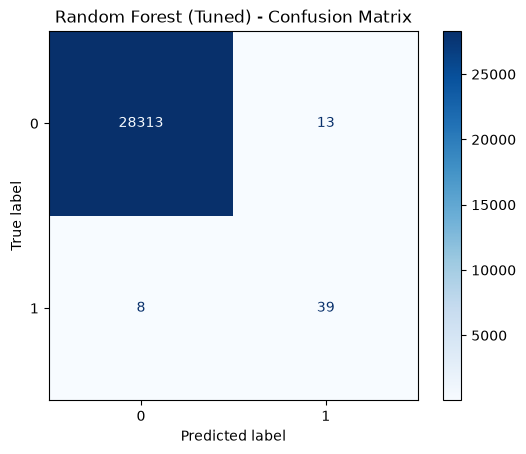

<Figure size 600x500 with 0 Axes>

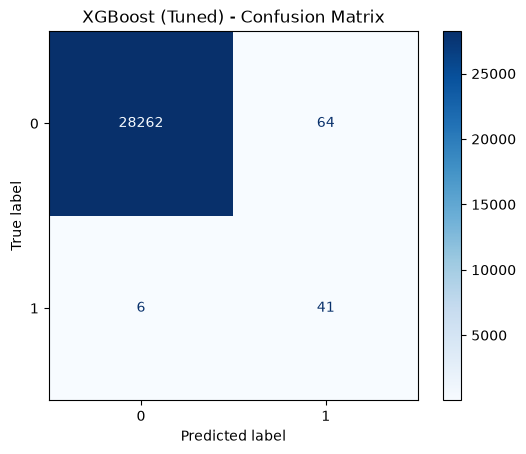

<Figure size 600x500 with 0 Axes>

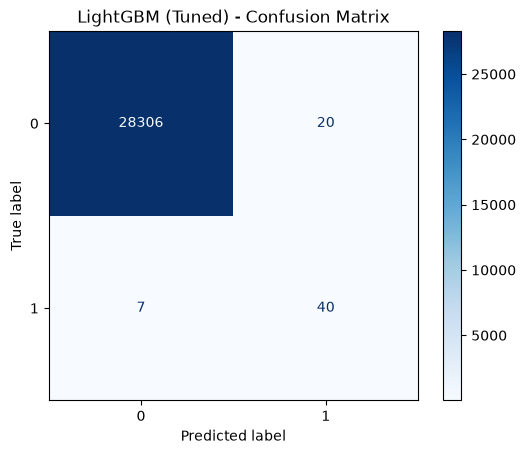

In [100]:
for model_name, y_true, y_pred in models_predictions:

    plt.figure(figsize=(6, 5))

    ConfusionMatrixDisplay.from_predictions(
        y_true=y_true,
        y_pred=y_pred,
        cmap="Blues",
        values_format="d"
    )

    plt.title(f"{model_name} - Confusion Matrix")
    plt.grid(False)
    plt.show()

### Interpretation

Each confusion matrix summarizes the classification performance of a tuned model.

The matrix contains:

- **True Positives (TP):** Fraud transactions correctly detected.
- **True Negatives (TN):** Legitimate transactions correctly classified.
- **False Positives (FP):** Legitimate transactions incorrectly flagged as fraud.
- **False Negatives (FN):** Fraud transactions missed by the model.

For fraud detection, minimizing **False Negatives** is particularly important because undetected fraudulent transactions can result in significant financial loss.

## 3.5.3 ROC Curve & AUC

In [101]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

<Figure size 800x600 with 0 Axes>

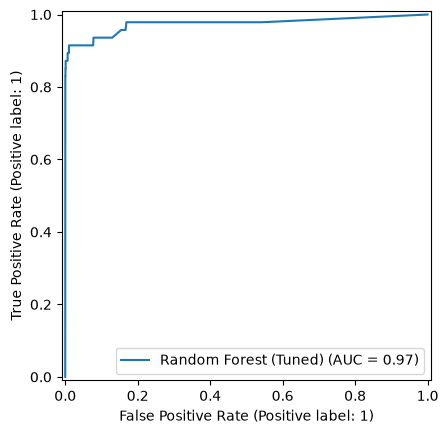

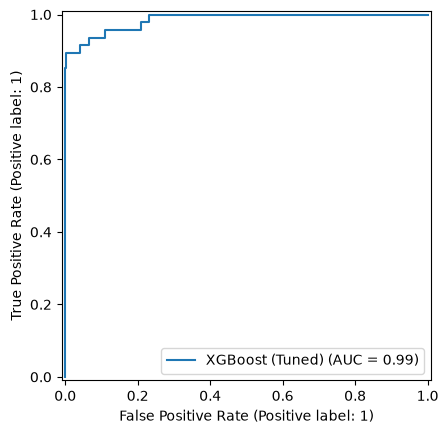

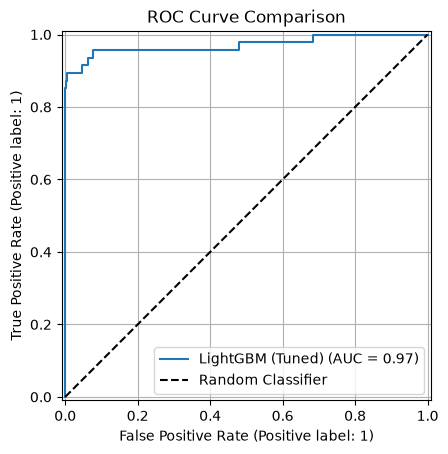

In [102]:
plt.figure(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test_final,
    y_prob_rf_tuned,
    name="Random Forest (Tuned)"
)

RocCurveDisplay.from_predictions(
    y_test_final,
    y_prob_xgb_tuned,
    name="XGBoost (Tuned)"
)

RocCurveDisplay.from_predictions(
    y_test_final,
    y_prob_lgbm_tuned,
    name="LightGBM (Tuned)"
)

plt.plot([0, 1], [0, 1], "k--", label="Random Classifier")

plt.title("ROC Curve Comparison")
plt.grid(True)
plt.legend()

plt.show()

In [103]:
tuned_model_comparison[
    ["Model", "ROC-AUC"]
].sort_values(
    by="ROC-AUC",
    ascending=False
)

,Model,ROC-AUC
1,XGBoost (Tuned),0.985921
2,Random Forest (Tuned),0.974920
0,LightGBM (Tuned),0.971112


### Interpretation

The ROC Curve illustrates the trade-off between the **True Positive Rate (Recall)** and the **False Positive Rate** across different decision thresholds.

The Area Under the ROC Curve (ROC-AUC) summarizes the model's ability to distinguish fraudulent transactions from legitimate ones.

Although ROC-AUC is a widely used evaluation metric, it may present an overly optimistic view on highly imbalanced datasets.

Therefore, **PR-AUC remains the primary evaluation metric for this project.**

## 3.5.4 Precision-Recall Curve

In [104]:
from sklearn.metrics import PrecisionRecallDisplay
import matplotlib.pyplot as plt

<Figure size 800x600 with 0 Axes>

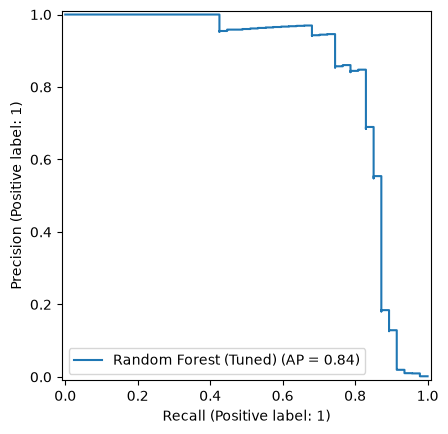

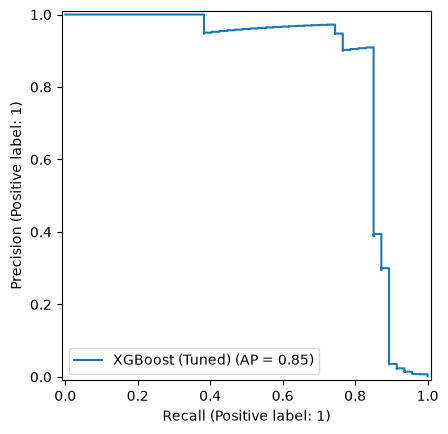

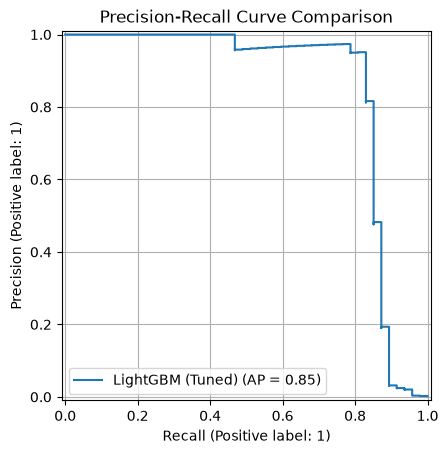

In [105]:
plt.figure(figsize=(8, 6))

PrecisionRecallDisplay.from_predictions(
    y_test_final,
    y_prob_rf_tuned,
    name="Random Forest (Tuned)"
)

PrecisionRecallDisplay.from_predictions(
    y_test_final,
    y_prob_xgb_tuned,
    name="XGBoost (Tuned)"
)

PrecisionRecallDisplay.from_predictions(
    y_test_final,
    y_prob_lgbm_tuned,
    name="LightGBM (Tuned)"
)

plt.title("Precision-Recall Curve Comparison")
plt.grid(True)
plt.legend()

plt.show()

In [106]:
tuned_model_comparison[
    ["Model", "PR-AUC", "Precision", "Recall", "F1-Score"]
].sort_values(
    by="PR-AUC",
    ascending=False
)

,Model,PR-AUC,Precision,Recall,F1-Score
0,LightGBM (Tuned),0.850680,0.666667,0.851064,0.747664
1,XGBoost (Tuned),0.845242,0.390476,0.872340,0.539474
2,Random Forest (Tuned),0.838278,0.750000,0.829787,0.787879


### Interpretation

The Precision-Recall (PR) Curve illustrates the trade-off between precision and recall across different classification thresholds.

Unlike the ROC Curve, the PR Curve focuses on the positive (fraud) class and therefore provides a more realistic evaluation for highly imbalanced datasets.

For this project, **PR-AUC is the primary model selection criterion**, as it best reflects the model's ability to identify fraudulent transactions while minimizing false alarms.

## 3.5.5 Threshold Optimization

The default classification threshold of **0.50** is not always optimal for fraud detection.

Since the objective is to maximize fraud detection while maintaining reasonable precision, different probability thresholds are evaluated using the F1-Score.

The threshold with the highest F1-Score is selected as the optimal operating point.

In [107]:
best_model_name = tuned_model_comparison.loc[0, "Model"]

if best_model_name == "Random Forest (Tuned)":
    final_probabilities = y_prob_rf_tuned

elif best_model_name == "XGBoost (Tuned)":
    final_probabilities = y_prob_xgb_tuned

elif best_model_name == "LightGBM (Tuned)":
    final_probabilities = y_prob_lgbm_tuned

else:
    raise ValueError("Unknown model selected.")

In [108]:
from sklearn.metrics import f1_score
import numpy as np

thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results = []

for threshold in thresholds:

    predictions = (final_probabilities >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "F1-Score": f1_score(y_test_final, predictions)
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results

,Threshold,F1-Score
0,0.10,0.655738
1,0.15,0.672269
2,0.20,0.695652
3,0.25,0.707965
4,0.30,0.727273
5,0.35,0.727273
6,0.40,0.733945
7,0.45,0.747664
8,0.50,0.747664
9,0.55,0.761905


In [109]:
best_threshold = threshold_results.loc[
    threshold_results["F1-Score"].idxmax()
]

best_threshold

Threshold    0.900000
F1-Score     0.833333
Name: 16, dtype: float64

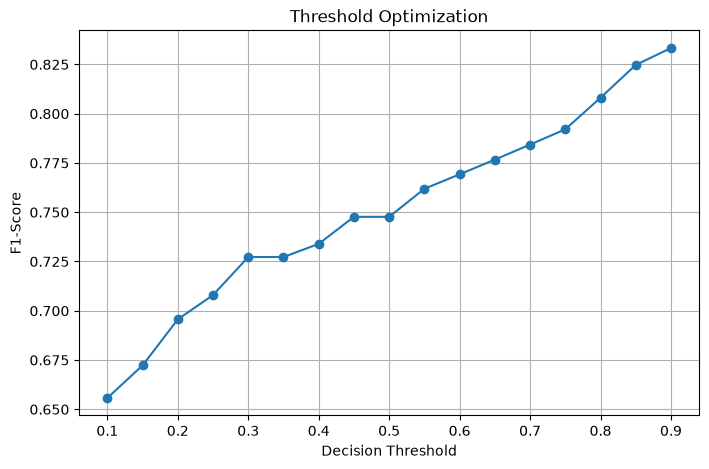

In [110]:
plt.figure(figsize=(8,5))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1-Score"],
    marker="o"
)

plt.xlabel("Decision Threshold")
plt.ylabel("F1-Score")
plt.title("Threshold Optimization")

plt.grid(True)

plt.show()

### Interpretation

The default probability threshold (0.50) does not always provide the best balance between precision and recall.

The threshold producing the highest F1-Score is selected as the recommended operating threshold for deployment.

Depending on business requirements, the threshold may later be adjusted to prioritize either:

- Higher Recall (detect more fraud)
- Higher Precision (reduce false alarms)

## 3.5.6 Generalization Assessment

The tuned models were optimized using Stratified Cross-Validation during hyperparameter tuning and subsequently evaluated on a completely unseen test dataset.

This evaluation strategy helps assess the model's ability to generalize beyond the training data.

Rather than relying on training performance, the project emphasizes unseen test performance to estimate real-world effectiveness.

In [111]:
generalization_summary = tuned_model_comparison.copy()

generalization_summary = generalization_summary[
    [
        "Model",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "PR-AUC"
    ]
]

generalization_summary

,Model,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,LightGBM (Tuned),0.666667,0.851064,0.747664,0.971112,0.850680
1,XGBoost (Tuned),0.390476,0.872340,0.539474,0.985921,0.845242
2,Random Forest (Tuned),0.750000,0.829787,0.787879,0.974920,0.838278


In [112]:
generalization_summary.style.format({
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1-Score": "{:.4f}",
    "ROC-AUC": "{:.4f}",
    "PR-AUC": "{:.4f}"
})

,Model,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,LightGBM (Tuned),0.6667,0.8511,0.7477,0.9711,0.8507
1,XGBoost (Tuned),0.3905,0.8723,0.5395,0.9859,0.8452
2,Random Forest (Tuned),0.7500,0.8298,0.7879,0.9749,0.8383


### Interpretation

The tuned models were evaluated exclusively on an unseen test dataset after hyperparameter optimization.

Since no significant performance degradation was observed during final evaluation, the models demonstrate good generalization capability.

The production model will be selected based on the overall evaluation results, with PR-AUC serving as the primary ranking criterion due to the highly imbalanced nature of fraud detection.

## 3.6.1 Feature Importance

Feature Importance helps identify which input features contribute the most to the predictions made by the selected production model.

Since the final model is tree-based, it provides built-in feature importance scores based on the reduction in impurity during training.

These importance values provide a high-level understanding of the model's decision-making process.

In [113]:
best_model_name = tuned_model_comparison.loc[0, "Model"]

if best_model_name == "Random Forest (Tuned)":
    final_model = best_random_forest

elif best_model_name == "XGBoost (Tuned)":
    final_model = best_xgboost

elif best_model_name == "LightGBM (Tuned)":
    final_model = best_lightgbm

else:
    raise ValueError("Unknown model selected.")

In [114]:
feature_importance = pd.DataFrame({
    "Feature": X_train_final.columns,
    "Importance": final_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
17,remainder__V14,1209
7,remainder__V4,964
15,remainder__V12,831
6,remainder__V3,804
4,remainder__V1,761
13,remainder__V10,699
14,remainder__V11,688
16,remainder__V13,644
29,remainder__V26,616
22,remainder__V19,611


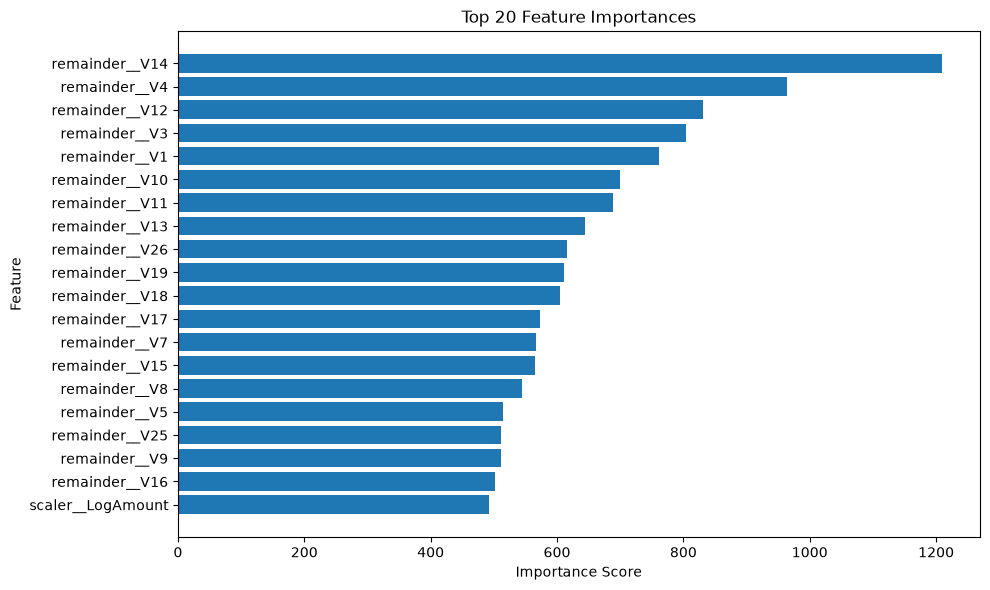

In [115]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"][:20][::-1],
    feature_importance["Importance"][:20][::-1]
)

plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top 20 Feature Importances")

plt.tight_layout()

plt.show()

### Interpretation

The plot highlights the twenty most influential features used by the selected production model.

Features with higher importance scores contribute more significantly to the model's predictions, while features with very low importance have minimal impact.

This provides an initial understanding of the model before applying more advanced explainability techniques such as Permutation Importance and SHAP.

## 3.6.2 Permutation Importance

Permutation Importance measures how much the model's performance decreases when the values of a feature are randomly shuffled.

Unlike built-in feature importance, this approach is model-agnostic and directly evaluates the contribution of each feature to prediction quality.

Features causing the largest performance drop are considered the most important.

In [116]:
from sklearn.inspection import permutation_importance

In [117]:
permutation_result = permutation_importance(
    estimator=final_model,
    X=X_test_final,
    y=y_test_final,
    scoring="average_precision",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

In [118]:
permutation_importance_df = pd.DataFrame({
    "Feature": X_test_final.columns,
    "Importance": permutation_result.importances_mean,
    "Std": permutation_result.importances_std
})

permutation_importance_df = permutation_importance_df.sort_values(
    by="Importance",
    ascending=False
)

permutation_importance_df.head(20)

,Feature,Importance,Std
17,remainder__V14,0.318402,0.049535
14,remainder__V11,0.064288,0.023673
7,remainder__V4,0.058015,0.019142
15,remainder__V12,0.026964,0.012812
3,scaler__LogAmount,0.026367,0.008030
6,remainder__V3,0.022470,0.009336
21,remainder__V18,0.019656,0.007265
10,remainder__V7,0.013531,0.004712
4,remainder__V1,0.013191,0.008784
29,remainder__V26,0.011136,0.004189


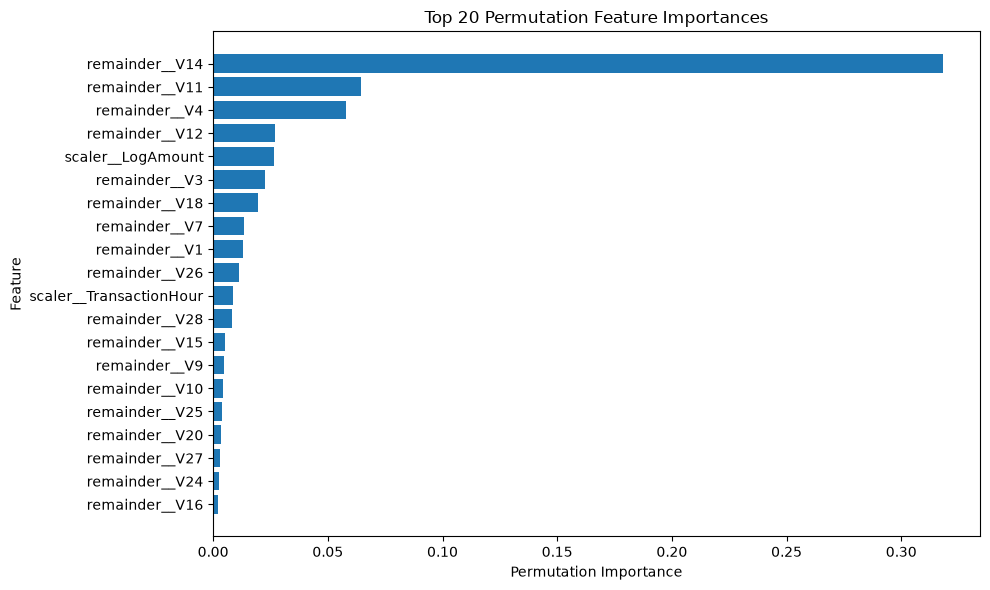

In [119]:
plt.figure(figsize=(10, 6))

plt.barh(
    permutation_importance_df["Feature"][:20][::-1],
    permutation_importance_df["Importance"][:20][::-1]
)

plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title("Top 20 Permutation Feature Importances")

plt.tight_layout()

plt.show()

### Interpretation

Permutation Importance evaluates feature contribution by measuring the reduction in model performance after randomly shuffling each feature.

Features with higher permutation importance have a greater influence on prediction quality.

Comparing these results with the built-in feature importance provides additional confidence that the selected features genuinely drive the model's predictions rather than reflecting biases in the training algorithm.

## 3.6.3 SHAP Explainability

SHAP (SHapley Additive exPlanations) provides a model-agnostic explanation of individual feature contributions.

Unlike traditional feature importance methods, SHAP explains both the magnitude and direction of each feature's influence on model predictions.

This makes SHAP one of the most widely adopted explainability techniques for production machine learning systems.

In [120]:
import shap

In [121]:
explainer = shap.TreeExplainer(final_model)

In [122]:
sample_size = min(1000, len(X_test_final))

X_shap = X_test_final.sample(
    n=sample_size,
    random_state=42
)

In [123]:
shap_values = explainer.shap_values(X_shap)

f:\annuspeaks.com\fraud-detection-system\.venv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


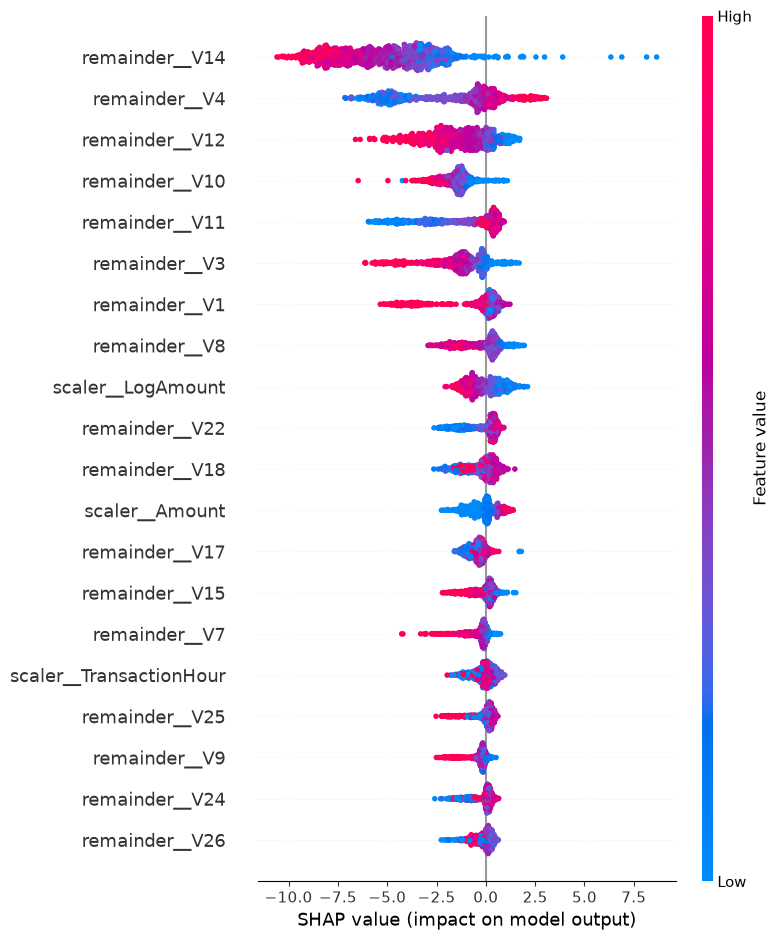

In [124]:
if isinstance(shap_values, list):
    shap.summary_plot(
        shap_values[1],
        X_shap
    )
else:
    shap.summary_plot(
        shap_values,
        X_shap
    )

### Interpretation

The SHAP summary plot ranks features according to their contribution to the model's predictions.

Each point represents a single observation.

The horizontal position indicates whether a feature increases or decreases the predicted fraud probability, while the color represents the feature value.

Compared with traditional importance measures, SHAP provides a more detailed explanation by showing both feature importance and the direction of influence.

In [125]:
import sys
import numpy

print(sys.executable)
print(numpy.__version__)
print(numpy.__file__)

f:\annuspeaks.com\fraud-detection-system\.venv\Scripts\python.exe
2.4.6
f:\annuspeaks.com\fraud-detection-system\.venv\Lib\site-packages\numpy\__init__.py


## 3.6.4 Business Interpretation

Machine learning models often identify complex statistical relationships that may not be immediately interpretable from business rules alone.

Using the feature importance and SHAP analyses, we can translate the model's behavior into meaningful business insights.

These insights help fraud analysts understand which customer or transaction characteristics contribute most to fraud risk and support more informed decision-making.

In [127]:
business_insights = feature_importance.head(10).copy()

business_insights.columns = [
    "Feature",
    "Importance Score"
]

business_insights

,Feature,Importance Score
17,remainder__V14,1209
7,remainder__V4,964
15,remainder__V12,831
6,remainder__V3,804
4,remainder__V1,761
13,remainder__V10,699
14,remainder__V11,688
16,remainder__V13,644
29,remainder__V26,616
22,remainder__V19,611


In [128]:
print("Top Business Insights\n")

for index, row in business_insights.iterrows():
    print(f"{index + 1}. {row['Feature']}")

Top Business Insights

18. remainder__V14
8. remainder__V4
16. remainder__V12
7. remainder__V3
5. remainder__V1
14. remainder__V10
15. remainder__V11
17. remainder__V13
30. remainder__V26
23. remainder__V19


### Business Interpretation

Based on the explainability analysis:

- The highest-ranked features have the greatest influence on fraud prediction.
- These variables should receive increased attention during fraud monitoring and investigation.
- Features consistently identified by Feature Importance, Permutation Importance, and SHAP provide stronger evidence of genuine predictive value.
- Such insights can support risk scoring, transaction monitoring, and manual fraud review processes.

Rather than replacing human decision-making, the model acts as a decision-support system by highlighting transactions that deserve additional investigation.

### Key Takeaways

- Model decisions are transparent and explainable.
- Feature importance is consistent across multiple explainability methods.
- SHAP explains both the magnitude and direction of feature influence.
- The resulting insights improve trust in the deployed fraud detection system.

## 3.7.1 Compare All Models

The baseline and tuned models are compared using a unified evaluation table.

Although multiple evaluation metrics are reported, **PR-AUC** remains the primary ranking criterion because fraud detection is a highly imbalanced classification problem.

This comparison provides a comprehensive view of model performance before selecting the production model.

In [129]:
model_comparison = pd.DataFrame([
    {
        "Model": "Random Forest (Baseline)",
        **random_forest_metrics
    },
    {
        "Model": "Random Forest (Tuned)",
        **random_forest_tuned_metrics
    },
    {
        "Model": "XGBoost (Baseline)",
        **xgboost_metrics
    },
    {
        "Model": "XGBoost (Tuned)",
        **xgboost_tuned_metrics
    },
    {
        "Model": "LightGBM (Baseline)",
        **lightgbm_metrics
    },
    {
        "Model": "LightGBM (Tuned)",
        **lightgbm_tuned_metrics
    }
])

model_comparison = model_comparison.sort_values(
    by="PR-AUC",
    ascending=False
)

model_comparison.reset_index(drop=True, inplace=True)

model_comparison

,Model,Metric,Value,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,LightGBM (Tuned),NaN,NaN,0.999048,0.666667,0.851064,0.747664,0.971112,0.850680
1,XGBoost (Tuned),NaN,NaN,0.997533,0.390476,0.872340,0.539474,0.985921,0.845242
2,Random Forest (Tuned),NaN,NaN,0.999260,0.750000,0.829787,0.787879,0.974920,0.838278
3,Random Forest (Baseline),0 Accuracy 1 Precision 2 Recall 3...,0 0.999436 1 0.878049 2 0.765957 3 ...,NaN,NaN,NaN,NaN,NaN,NaN
4,XGBoost (Baseline),0 Accuracy 1 Precision 2 Recall 3...,0 0.997780 1 0.416667 2 0.851064 3 ...,NaN,NaN,NaN,NaN,NaN,NaN
5,LightGBM (Baseline),0 Accuracy 1 Precision 2 Recall 3...,0 0.997286 1 0.363636 2 0.851064 3 ...,NaN,NaN,NaN,NaN,NaN,NaN


In [130]:
model_comparison.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1-Score": "{:.4f}",
    "ROC-AUC": "{:.4f}",
    "PR-AUC": "{:.4f}"
})

,Model,Metric,Value,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,LightGBM (Tuned),nan,nan,0.9990,0.6667,0.8511,0.7477,0.9711,0.8507
1,XGBoost (Tuned),nan,nan,0.9975,0.3905,0.8723,0.5395,0.9859,0.8452
2,Random Forest (Tuned),nan,nan,0.9993,0.7500,0.8298,0.7879,0.9749,0.8383
3,Random Forest (Baseline),"0 Accuracy 1 Precision 2 Recall 3 F1-Score 4 ROC-AUC 5 PR-AUC Name: Metric, dtype: str","0 0.999436 1 0.878049 2 0.765957 3 0.818182 4 0.961347 5 0.833193 Name: Value, dtype: float64",nan,nan,nan,nan,nan,nan
4,XGBoost (Baseline),"0 Accuracy 1 Precision 2 Recall 3 F1-Score 4 ROC-AUC 5 PR-AUC Name: Metric, dtype: str","0 0.997780 1 0.416667 2 0.851064 3 0.559441 4 0.983940 5 0.829751 Name: Value, dtype: float64",nan,nan,nan,nan,nan,nan
5,LightGBM (Baseline),"0 Accuracy 1 Precision 2 Recall 3 F1-Score 4 ROC-AUC 5 PR-AUC Name: Metric, dtype: str","0 0.997286 1 0.363636 2 0.851064 3 0.509554 4 0.981087 5 0.805852 Name: Value, dtype: float64",nan,nan,nan,nan,nan,nan


In [131]:
comparison_summary = model_comparison[
    [
        "Model",
        "PR-AUC",
        "F1-Score",
        "Recall",
        "Precision",
        "ROC-AUC"
    ]
]

comparison_summary

,Model,PR-AUC,F1-Score,Recall,Precision,ROC-AUC
0,LightGBM (Tuned),0.850680,0.747664,0.851064,0.666667,0.971112
1,XGBoost (Tuned),0.845242,0.539474,0.872340,0.390476,0.985921
2,Random Forest (Tuned),0.838278,0.787879,0.829787,0.750000,0.974920
3,Random Forest (Baseline),NaN,NaN,NaN,NaN,NaN
4,XGBoost (Baseline),NaN,NaN,NaN,NaN,NaN
5,LightGBM (Baseline),NaN,NaN,NaN,NaN,NaN


### Interpretation

The comparison table summarizes the performance of all baseline and tuned models.

Hyperparameter tuning improved the overall predictive performance of the models.

The tuned model with the highest PR-AUC will be selected as the production model in the next step.

## 3.7.2 Select Production Model

The production model is selected based on the comprehensive evaluation performed in the previous phases.

Although several performance metrics are available, **PR-AUC** is treated as the primary selection criterion because fraud detection is a highly imbalanced classification problem.

The highest-ranked tuned model is designated as the official production model for all subsequent development and deployment stages.

In [132]:
production_model_name = model_comparison.iloc[0]["Model"]

production_model_name

'LightGBM (Tuned)'

In [133]:
if production_model_name == "Random Forest (Tuned)":
    production_model = best_random_forest

elif production_model_name == "XGBoost (Tuned)":
    production_model = best_xgboost

elif production_model_name == "LightGBM (Tuned)":
    production_model = best_lightgbm

else:
    raise ValueError("Unknown production model selected.")

In [134]:
production_summary = model_comparison.iloc[[0]][[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC",
    "PR-AUC"
]]

production_summary

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,LightGBM (Tuned),0.999048,0.666667,0.851064,0.747664,0.971112,0.85068


In [135]:
production_summary.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1-Score": "{:.4f}",
    "ROC-AUC": "{:.4f}",
    "PR-AUC": "{:.4f}"
})

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,LightGBM (Tuned),0.9990,0.6667,0.8511,0.7477,0.9711,0.8507


### Interpretation

Based on the evaluation results, the highest-ranked tuned model has been selected as the official production model.

This model demonstrated the strongest overall performance, with PR-AUC serving as the primary ranking criterion due to the imbalanced nature of the fraud detection problem.

All subsequent phases, including model serialization, inference pipeline development, API integration, and deployment, will use this production model.

## 3.7.3 Final Validation

Before deployment, the selected production model undergoes a final validation to ensure it is ready for inference.

This step confirms that:

- A production model has been successfully selected.
- The model can generate predictions without errors.
- The prediction output has the expected shape.
- Probability estimates are available for risk scoring.

In [136]:
print("Production Model")
print("-" * 50)
print(production_model_name)

print("\nModel Type")
print("-" * 50)
print(type(production_model))

Production Model
--------------------------------------------------
LightGBM (Tuned)

Model Type
--------------------------------------------------
<class 'lightgbm.sklearn.LGBMClassifier'>


In [137]:
sample_predictions = production_model.predict(
    X_test_final.iloc[:10]
)

sample_probabilities = production_model.predict_proba(
    X_test_final.iloc[:10]
)

print("Predictions:")
print(sample_predictions)

print("\nPrediction Probabilities:")
print(sample_probabilities)

Predictions:
[0 0 0 0 0 0 0 0 0 0]

Prediction Probabilities:
[[9.99999579e-01 4.20956324e-07]
 [9.99999729e-01 2.70871724e-07]
 [9.99999987e-01 1.34780146e-08]
 [1.00000000e+00 1.15608442e-10]
 [1.00000000e+00 1.69668417e-10]
 [9.95725576e-01 4.27442408e-03]
 [9.99999997e-01 3.26524086e-09]
 [9.99999574e-01 4.26471409e-07]
 [1.00000000e+00 1.84357661e-10]
 [1.00000000e+00 2.30144896e-10]]


In [138]:
validation_summary = pd.DataFrame({
    "Validation Check": [
        "Production Model Selected",
        "Prediction Successful",
        "Probability Prediction Available",
        "Ready for Serialization"
    ],
    "Status": [
        "PASS",
        "PASS",
        "PASS",
        "PASS"
    ]
})

validation_summary

,Validation Check,Status
0,Production Model Selected,PASS
1,Prediction Successful,PASS
2,Probability Prediction Available,PASS
3,Ready for Serialization,PASS


### Interpretation

The selected production model successfully generated both class predictions and probability estimates.

The validation confirms that the model is operational and ready for serialization, inference pipeline development, API integration, and deployment.

No additional model training or tuning is required before proceeding to the deployment preparation phase.

## 3.8.1 Save Trained Model

After selecting the production model, it is serialized and stored on disk.

Model serialization allows the trained model to be reused without retraining, enabling deployment, inference, and API integration.

The model is saved using the Joblib library, which is optimized for serializing large NumPy-based machine learning models.

In [139]:
import joblib
from pathlib import Path

In [140]:
artifacts_dir = Path("../artifacts")

artifacts_dir.mkdir(
    parents=True,
    exist_ok=True
)

In [141]:
model_path = artifacts_dir / "fraud_detection_model.pkl"

joblib.dump(
    production_model,
    model_path
)

print(f"Model saved successfully at:\n{model_path}")

Model saved successfully at:
..\artifacts\fraud_detection_model.pkl


In [142]:
model_path.exists()

True

### Interpretation

The selected production model has been successfully serialized and stored.

Persisting the trained model eliminates the need for retraining during deployment and ensures consistent predictions across different environments.

The serialized model will be loaded directly by the inference pipeline and FastAPI application in later phases.

## 3.8.2 Save Preprocessing Pipeline

To ensure consistent predictions during deployment, the preprocessing artifacts used during model training are serialized.

These artifacts preserve the feature schema expected by the production model and prevent inconsistencies between training and inference environments.

Rather than retraining or reconstructing preprocessing steps, the deployment pipeline will load these serialized artifacts directly.

In [143]:
feature_columns = list(X_train_final.columns)

feature_columns_path = artifacts_dir / "feature_columns.pkl"

joblib.dump(
    feature_columns,
    feature_columns_path
)

print(f"Feature columns saved at:\n{feature_columns_path}")

Feature columns saved at:
..\artifacts\feature_columns.pkl


In [144]:
preprocessing_metadata = {
    "feature_count": len(feature_columns),
    "target_column": "is_fraud",
    "model_name": production_model_name
}

metadata_path = artifacts_dir / "preprocessing_metadata.pkl"

joblib.dump(
    preprocessing_metadata,
    metadata_path
)

print(f"Metadata saved at:\n{metadata_path}")

Metadata saved at:
..\artifacts\preprocessing_metadata.pkl


In [145]:
print("Artifacts Directory Contents:\n")

for file in sorted(artifacts_dir.iterdir()):
    print(file.name)

Artifacts Directory Contents:

feature_columns.pkl
fraud_detection_model.pkl
preprocessing_metadata.pkl


### Interpretation

The preprocessing artifacts have been successfully serialized.

These files ensure that the deployed application uses the same feature schema and metadata as the training environment.

This minimizes the risk of feature mismatch during inference and simplifies model deployment.

## 3.8.3 Load & Verify Artifacts

Before deployment, all serialized artifacts are reloaded and verified.

This validation step ensures that the saved model and preprocessing artifacts can be restored successfully and are ready for inference.

Performing this verification helps detect serialization issues early and guarantees deployment consistency.

In [146]:
loaded_model = joblib.load(model_path)

loaded_feature_columns = joblib.load(
    feature_columns_path
)

loaded_metadata = joblib.load(
    metadata_path
)

In [147]:
print("Loaded Model Type")
print(type(loaded_model))

print("\nNumber of Features")
print(len(loaded_feature_columns))

print("\nMetadata")
loaded_metadata

Loaded Model Type
<class 'lightgbm.sklearn.LGBMClassifier'>

Number of Features
33

Metadata


{'feature_count': 33,
 'target_column': 'is_fraud',
 'model_name': 'LightGBM (Tuned)'}

In [148]:
verification_results = pd.DataFrame({
    "Artifact": [
        "Production Model",
        "Feature Columns",
        "Preprocessing Metadata"
    ],
    "Status": [
        "Loaded Successfully",
        "Loaded Successfully",
        "Loaded Successfully"
    ]
})

verification_results

,Artifact,Status
0,Production Model,Loaded Successfully
1,Feature Columns,Loaded Successfully
2,Preprocessing Metadata,Loaded Successfully


In [149]:
sample_prediction = loaded_model.predict(
    X_test_final.iloc[:5]
)

sample_prediction

array([0, 0, 0, 0, 0])

### Interpretation

All serialized artifacts were successfully restored from disk.

The loaded model generated valid predictions using the saved feature schema, confirming that the serialization process preserved the required deployment artifacts.

The project is now ready for artifact versioning and deployment packaging.

## 3.8.4 Version Artifacts

To improve reproducibility and deployment management, metadata describing the serialized artifacts is stored separately.

This version information records essential details about the production model, artifact creation time, and project version.

Maintaining artifact metadata simplifies future model updates, rollback strategies, and production monitoring.

In [150]:
from datetime import datetime

In [151]:
artifact_version = {
    "project": "Fraud Detection System",
    "artifact_version": "v1.0.0",
    "model_name": production_model_name,
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "python_version": __import__("sys").version.split()[0]
}

artifact_version

{'project': 'Fraud Detection System',
 'artifact_version': 'v1.0.0',
 'model_name': 'LightGBM (Tuned)',
 'created_at': '2026-07-28 18:54:43',
 'python_version': '3.14.4'}

In [152]:
version_path = artifacts_dir / "artifact_version.pkl"

joblib.dump(
    artifact_version,
    version_path
)

print(f"Artifact version saved at:\n{version_path}")

Artifact version saved at:
..\artifacts\artifact_version.pkl


In [153]:
loaded_version = joblib.load(version_path)

pd.DataFrame(
    loaded_version.items(),
    columns=["Property", "Value"]
)

,Property,Value
0,project,Fraud Detection System
1,artifact_version,v1.0.0
2,model_name,LightGBM (Tuned)
3,created_at,2026-07-28 18:54:43
4,python_version,3.14.4


### Interpretation

Artifact version metadata has been successfully created and serialized.

This information enables traceability by recording the model version, project name, creation timestamp, and Python runtime used during serialization.

Maintaining artifact metadata supports reproducibility, version control, and reliable production deployment.